In [1]:
!pip install torch --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [5]:
import torch
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch CUDA available: False


In [1]:
# Uninstall current PyTorch first
!pip uninstall torch torchvision torchaudio -y

# Install PyTorch with CUDA 12.1 (matching your driver's CUDA 13.0)
!pip install torch --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.10.0
Uninstalling torch-2.10.0:
  Successfully uninstalled torch-2.10.0
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.5/780.5 MB 140.6 MB/s  0:00:0300:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 205.6 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 114.1 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 212.5 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 149.9 MB/s  0:00:0300:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 191.5 MB/s  0:00:0100:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 222.0 MB/s  0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 213.1 MB/s  0:00:000:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 224.2 MB/s  0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/

In [2]:
!pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121


In [3]:
!pip install torch --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp311-cp311-linux_x86_64.whl (780.5 MB)


In [1]:
import torch
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch CUDA available: True
GPU: NVIDIA GeForce GTX 1080 Ti


In [1]:
import numpy as np
import pandas as pd

DRIVE_URL = "https://drive.google.com/uc?id=1PS0eB8dx8VMzVvxNUc6wBzsMRkEKJjWI"
df = pd.read_csv(DRIVE_URL)

# ---------------- Physics rebuild ----------------
M_p = 938.272088
M_n = 939.565420
epsilon = 1e-30
LN10 = np.log(10.0)

def mass(Z,A): 
    return Z*M_p + (A-Z)*M_n

df["N1"] = df["A1"] - df["Z1"]
df["N2"] = df["A2"] - df["Z2"]

df["mass1"] = mass(df["Z1"], df["A1"])
df["mass2"] = mass(df["Z2"], df["A2"])

mu_red = (df["mass1"] * df["mass2"]) / (df["mass1"] + df["mass2"] + 1e-12)
v_over_c = np.sqrt(np.clip(2*df["E c.m."].values/(mu_red+epsilon),0,np.inf))
df["eta"] = (df["Z1"]*df["Z2"]) / ((1/137.036)*(v_over_c+1e-16))

df["Z1Z2_over_Ecm"] = (df["Z1"]*df["Z2"]) / (df["E c.m."] + epsilon)

MAGIC = np.array([2,8,20,28,50,82,126])
df["magic_dist_Z1"] = np.min(np.abs(df["Z1"].values[:,None] - MAGIC), axis=1)
df["magic_dist_N1"] = np.min(np.abs(df["N1"].values[:,None] - MAGIC), axis=1)
df["magic_dist_Z2"] = np.min(np.abs(df["Z2"].values[:,None] - MAGIC), axis=1)
df["magic_dist_N2"] = np.min(np.abs(df["N2"].values[:,None] - MAGIC), axis=1)

# Coulomb barrier
barrier_df = df.groupby("Reaction").first().reset_index()
barrier_df["V_B"] = (barrier_df["Z1"]*barrier_df["Z2"]*1.44) / barrier_df["R B"]
df = df.merge(barrier_df[["Reaction","V_B"]], on="Reaction", how="left")




# Coulomb parameter
v_over_c = np.sqrt(np.clip(2*df["E c.m."].values / (mu_red + epsilon), 0, np.inf))
e2_hbar_c = 1/137.035999

df["eta"] = (df["Z1"] * df["Z2"]) / (e2_hbar_c * (v_over_c + 1e-16))

# S-factor logs
log10_sigma_exp = np.log10(np.clip(df["σ"], 1e-30, np.inf))
log10_sigma_cal = np.log10(np.clip(df["σ cal"], 1e-30, np.inf))
log10_Ecm = np.log10(np.clip(df["E c.m."], 1e-30, np.inf))

df["log10_S_exp"] = log10_sigma_exp + log10_Ecm + (2*np.pi*df["eta"])/LN10
df["log10_S_cal"] = log10_sigma_cal + log10_Ecm + (2*np.pi*df["eta"])/LN10

df["delta_log10_S"] = df["log10_S_exp"] - df["log10_S_cal"]

print("delta_log10_S created.")
print("Dataset ready.")
features_train = [
    'E c.m.', 'Z1', 'N1', 'A1',
    'Z2', 'N2', 'A2', 'Q ( 2 n )',
    'Z1Z2_over_Ecm',
    'magic_dist_Z1','magic_dist_N1','magic_dist_Z2','magic_dist_N2',
    'Z3','N3','A3','β P','β T','R B','ħ ω',
    'Projectile_Mass_Actual','Target_Mass_Actual','Compound_Nucleus_Mass_Actual',
    'Compound_Nucleus_Sp','Compound_Nucleus_Sn',
    'Projectile_Binding_Energy','Target_Binding_Energy',
    'Compound_Nucleus_Binding_Energy','Compound_Nucleus_S2n'
]


delta_log10_S created.
Dataset ready.


In [2]:
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import time
import matplotlib.pyplot as plt

# ---------- Device setup ----------
torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", torch_device)

# ---------- Hyperparameters (adjust these to scale up) ----------
n_qubits = 15                # Increase from 10 to 12 (or 14)
n_layers = 16                # Increase from 8 to 10 (or 12)
batch_size = 16              # Can increase to 128 if GPU memory allows
learning_rate = 1e-3
epochs = 100                 # Max epochs (early stopping will stop earlier)
patience = 10                # Stop if no improvement for 15 epochs

# PennyLane device (default.qubit with backprop – uses GPU automatically if tensors are on GPU)
dev = qml.device("default.qubit", wires=n_qubits)
# dev = qml.device("lightning.gpu", wires=n_qubits)

Using device: cuda


In [3]:
@qml.qnode(dev, interface="torch", diff_method="backprop")
# @qml.qnode(dev, interface="torch", diff_method="adjoint")
def qnode_single(weights, x):
    """
    weights: (n_layers, n_qubits, 3)
    x: (n_qubits,) – one sample
    """
    qml.templates.AngleEmbedding(x, wires=range(n_qubits))
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

In [4]:
class QuantumRegressor(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.encoder = nn.Linear(in_dim, n_qubits)
        self.q_weights = nn.Parameter(0.01 * torch.randn(n_layers, n_qubits, 3))
        self.fc1 = nn.Linear(n_qubits, 16)          # smaller head
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        x = x.float()
        x_enc = torch.tanh(self.encoder(x))
        q_out_tuple = qnode_single(self.q_weights, x_enc)
        q_out = torch.stack(q_out_tuple, dim=1)
        q_out = q_out.to(x.dtype)
        h = torch.relu(self.fc1(q_out))
        h = self.dropout(h)
        out = self.fc2(h)
        return out

In [5]:

# Extract X and y
X = df[features_train].values.astype(np.float32)
y = df["delta_log10_S"].values.astype(np.float32).reshape(-1, 1)

# Standardise features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reaction‑wise split (load your split files)
OUTDIR_BASE = "mdn_70_10_20_optimized"   # <--- ADJUST IF NEEDED
train_reacts = pd.read_csv(f"{OUTDIR_BASE}/train_reactions.csv")["Reaction"].values
val_reacts   = pd.read_csv(f"{OUTDIR_BASE}/val_reactions.csv")["Reaction"].values
test_reacts  = pd.read_csv(f"{OUTDIR_BASE}/test_reactions.csv")["Reaction"].values

train_mask = df["Reaction"].isin(train_reacts)
val_mask   = df["Reaction"].isin(val_reacts)
test_mask  = df["Reaction"].isin(test_reacts)

X_train = X_scaled[train_mask]
y_train = y[train_mask]
X_val   = X_scaled[val_mask]
y_val   = y[val_mask]
X_test  = X_scaled[test_mask]
y_test  = y[test_mask]

# Convert to torch tensors (CPU initially)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32)

# DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                          batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),
                          batch_size=batch_size, shuffle=False)

print(f"Train samples: {X_train.shape[0]}, Val samples: {X_val.shape[0]}, Test samples: {X_test.shape[0]}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train samples: 2493, Val samples: 354, Test samples: 685
Train batches: 156, Val batches: 23, Test batches: 43


In [6]:
model = QuantumRegressor(in_dim=29).to(torch_device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

# Early stopping variables
best_val_loss = float('inf')
patience_counter = 0
best_epoch = 0

print("Model parameters device:", next(model.parameters()).device)  # Should be cuda:0

Model parameters device: cuda:0


/srv/conda/envs/notebook/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [7]:
for epoch in range(epochs):
    # ---------- Training ----------
    model.train()
    train_loss = 0.0
    start_time = time.time()

    for xb, yb in train_loader:
        xb, yb = xb.to(torch_device), yb.to(torch_device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------- Validation ----------
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(torch_device), yb.to(torch_device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()
    val_loss /= len(val_loader)

    # Step the learning rate scheduler
    scheduler.step(val_loss)

    epoch_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:3d}/{epochs} | Time: {epoch_time:.2f}s | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | LR: {current_lr:.2e}")

    # ---------- Early Stopping Check ----------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
        print(f"  *** New best model saved (val loss: {val_loss:.6f}) ***")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after epoch {epoch+1} (best at epoch {best_epoch+1})")
            break

print("Training finished.")

Epoch   1/100 | Time: 220.73s | Train Loss: 0.084692 | Val Loss: 0.109192 | LR: 1.00e-03
  *** New best model saved (val loss: 0.109192) ***
Epoch   2/100 | Time: 220.38s | Train Loss: 0.073545 | Val Loss: 0.109438 | LR: 1.00e-03
Epoch   3/100 | Time: 220.14s | Train Loss: 0.070433 | Val Loss: 0.108752 | LR: 1.00e-03
  *** New best model saved (val loss: 0.108752) ***
Epoch   4/100 | Time: 221.20s | Train Loss: 0.067238 | Val Loss: 0.108652 | LR: 1.00e-03
  *** New best model saved (val loss: 0.108652) ***
Epoch   5/100 | Time: 220.42s | Train Loss: 0.063003 | Val Loss: 0.104495 | LR: 1.00e-03
  *** New best model saved (val loss: 0.104495) ***
Epoch   6/100 | Time: 221.35s | Train Loss: 0.061906 | Val Loss: 0.096815 | LR: 1.00e-03
  *** New best model saved (val loss: 0.096815) ***
Epoch   7/100 | Time: 221.08s | Train Loss: 0.058956 | Val Loss: 0.092059 | LR: 1.00e-03
  *** New best model saved (val loss: 0.092059) ***
Epoch   8/100 | Time: 222.56s | Train Loss: 0.057307 | Val Loss: 

In [10]:
# Load the best model
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

# Evaluate on test set
test_loss = 0.0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(torch_device), yb.to(torch_device)
        preds = model(xb)
        loss = criterion(preds, yb)
        test_loss += loss.item()
test_loss /= len(test_loader)

print(f"Test Loss (best model): {test_loss:.6f}")

/tmp/ipykernel_41665/1556161386.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))


Test Loss (best model): 0.039825


In [11]:
# Collect predictions for train/val/test
model.eval()
with torch.no_grad():
    train_pred = model(X_train_t.to(torch_device)).cpu().numpy()
    val_pred   = model(X_val_t.to(torch_device)).cpu().numpy()
    test_pred  = model(X_test_t.to(torch_device)).cpu().numpy()

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.scatter(y_train, train_pred, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title(f"Train (R² = {1 - np.var(y_train - train_pred)/np.var(y_train):.3f})")

plt.subplot(1,3,2)
plt.scatter(y_val, val_pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("True")
plt.title(f"Validation (R² = {1 - np.var(y_val - val_pred)/np.var(y_val):.3f})")

plt.subplot(1,3,3)
plt.scatter(y_test, test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("True")
plt.title(f"Test (R² = {1 - np.var(y_test - test_pred)/np.var(y_test):.3f})")

plt.tight_layout()
plt.show()

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.22 GiB. GPU 0 has a total capacity of 10.90 GiB of which 1.18 GiB is free. Process 3823050 has 216.00 MiB memory in use. Process 4112887 has 4.43 GiB memory in use. Process 3101238 has 2.44 GiB memory in use. Process 343485 has 2.65 GiB memory in use. Of the allocated memory 2.45 GiB is allocated by PyTorch, and 27.42 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [12]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

model.load_state_dict(torch.load("best_model.pt"))
model.eval()

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def evaluate_model(loader, name):
    preds = []
    truth = []
    
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(torch_device)
            out = model(xb)
            preds.append(out.cpu().numpy())
            truth.append(yb.numpy())
    
    preds = np.vstack(preds)
    truth = np.vstack(truth)
    
    mse = mean_squared_error(truth, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(truth, preds)
    
    print(f"\n{name} RESULTS")
    print(f"MSE  : {mse:.6f}")
    print(f"RMSE : {rmse:.6f}")
    print(f"R2   : {r2:.6f}")
    
    return r2, rmse


# ============================================================
# EVALUATE
# ============================================================

r2_train, rmse_train = evaluate_model(train_loader, "TRAIN")
r2_val, rmse_val     = evaluate_model(val_loader, "VALIDATION")
r2_test, rmse_test   = evaluate_model(test_loader, "TEST")

/tmp/ipykernel_41665/798825926.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))



TRAIN RESULTS
MSE  : 0.024053
RMSE : 0.155091
R2   : 0.692135

VALIDATION RESULTS
MSE  : 0.059147
RMSE : 0.243201
R2   : 0.453208

TEST RESULTS
MSE  : 0.039934
RMSE : 0.199835
R2   : 0.148006


In [13]:
# ==============================================
# LOAD BEST MODEL
# ==============================================

model = QuantumRegressor(in_dim=29)
model.load_state_dict(torch.load("best_model.pt", map_location=torch_device))
model.eval()
model.to(torch_device)

print("Best model loaded.")

Best model loaded.


/tmp/ipykernel_41665/1470981669.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt", map_location=torch_device))


In [14]:
# ==============================================
# EXTRACT QUANTUM EMBEDDINGS
# ==============================================

def extract_quantum_embeddings(model, X_tensor):
    
    model.eval()
    embeddings = []
    
    with torch.no_grad():
        for i in range(len(X_tensor)):
            
            x = X_tensor[i:i+1].to(torch_device)
            
            # Classical encoder
            x_enc = torch.tanh(model.encoder(x))
            
            # Quantum expectation values
            q_out_tuple = qnode_single(model.q_weights, x_enc)
            q_out = torch.stack(q_out_tuple, dim=1)
            
            embeddings.append(q_out.cpu().numpy())
    
    embeddings = np.vstack(embeddings)
    
    return embeddings


# Extract for entire dataset
X_all_tensor = torch.tensor(X_scaled, dtype=torch.float32)
quantum_embeddings = extract_quantum_embeddings(model, X_all_tensor)

print("Quantum embedding shape:", quantum_embeddings.shape)

Quantum embedding shape: (3532, 15)


In [15]:
# ==============================================
# REACTION-LEVEL QUANTUM EMBEDDING
# ==============================================

import pandas as pd
import numpy as np

# Attach embeddings to dataframe
df_embeddings = df.copy()
df_embeddings["Reaction"] = df["Reaction"]
df_embeddings["V_B"] = df["V_B"]

for i in range(quantum_embeddings.shape[1]):
    df_embeddings[f"q_{i}"] = quantum_embeddings[:, i]

# Compute reaction-level mean embedding
reaction_embeddings = (
    df_embeddings
    .groupby("Reaction")
    [[f"q_{i}" for i in range(quantum_embeddings.shape[1])]]
    .mean()
    .reset_index()
)

print("Reaction-level embedding shape:", reaction_embeddings.shape)
reaction_embeddings.head()

Reaction-level embedding shape: (213, 16)


,Reaction,q_0,q_1,q_2,q_3,q_4,q_5,q_6,q_7,q_8,q_9,q_10,q_11,q_12,q_13,q_14
0,12 C + 144 Sm,0.031505,0.031557,0.067068,0.018809,0.128334,0.127779,0.025316,0.204846,0.231384,0.060105,0.103844,0.042230,0.065047,0.041816,-0.014428
1,12 C + 152 Sm,0.118641,0.299793,0.112005,0.074513,0.096017,0.133877,0.081124,0.099658,0.170885,0.087887,0.111058,0.048944,0.366016,0.075631,0.011055
2,12 C + 154 Sm,0.132461,0.333235,0.136436,0.078150,0.090225,0.145521,0.083621,0.106767,0.171371,0.086856,0.112929,0.039942,0.369550,0.090355,0.016160
3,12 C + 181 Ta,0.089316,0.391058,0.042115,0.056174,0.043223,0.105957,0.038841,0.065476,0.107251,0.070635,0.123250,0.034157,0.447515,0.059604,0.033768
4,12 C + 194 Pt,0.035463,0.154488,0.014221,0.025063,0.075665,0.146803,0.044408,0.135844,0.147013,0.027392,0.134591,0.046205,0.127585,0.057413,0.005861


In [16]:
# ==============================================
# QUANTUM DISTANCE MATRIX (DYNAMIC)
# ==============================================

from sklearn.metrics import pairwise_distances

# Get all column names that start with 'q_' (the quantum features)
q_cols = [col for col in reaction_embeddings.columns if col.startswith('q_')]
print(f"Found {len(q_cols)} quantum feature columns.")

# Extract the quantum matrix
Q_matrix = reaction_embeddings[q_cols].values

# Euclidean distance
quantum_distance = pairwise_distances(Q_matrix, metric="euclidean")

print("Distance matrix shape:", quantum_distance.shape)
print("Distance min:", quantum_distance.min())
print("Distance max:", quantum_distance.max())

Found 15 quantum feature columns.
Distance matrix shape: (213, 213)
Distance min: 0.0
Distance max: 1.4722539913009494


In [17]:
# ==============================================
# LOAD CLASSICAL MDN ENSEMBLE (FOR SWITCH)
# ==============================================

import os
import numpy as np

OUTDIR_BASE = "mdn_70_10_20_optimized"
ENSEMBLE_DIR = os.path.join(OUTDIR_BASE, "ensembles_fast")

seed_dirs = sorted([
    os.path.join(ENSEMBLE_DIR, d)
    for d in os.listdir(ENSEMBLE_DIR)
    if d.startswith("seed_")
])

all_seed_components = []

for seed_path in seed_dirs:
    
    npz_path = os.path.join(seed_path, "mdn_all_components.npz")
    
    if not os.path.exists(npz_path):
        continue
    
    data = np.load(npz_path)
    
    all_seed_components.append({
        "pi": data["pi"]
    })

print("Loaded seeds:", len(all_seed_components))

Loaded seeds: 10


In [18]:
# ==========================================================
# RECOMPUTE ROBUST x_switch (CLASSICAL MDN)
# ==========================================================

import numpy as np
import pandas as pd

# ----------------------------------------------------
# Helper — compute switch for ONE seed
# ----------------------------------------------------

def compute_switch_per_seed(df, pi_array):
    
    df_temp = df.copy().reset_index(drop=True)
    df_temp["dominant"] = np.argmax(pi_array, axis=1)
    
    switch_dict = {}
    
    for reaction, sub in df_temp.groupby("Reaction"):
        
        sub = sub.sort_values("E c.m.").reset_index(drop=True)
        
        dom = sub["dominant"].values
        E_vals = sub["E c.m."].values
        
        if len(dom) < 2:
            continue
        
        switch_energy = np.nan
        
        for i in range(1, len(dom)):
            if dom[i] != dom[i-1]:
                switch_energy = E_vals[i]
                break
        
        if not np.isnan(switch_energy):
            
            V_B = sub["V_B"].iloc[0]
            x_switch = switch_energy / V_B
            
            switch_dict[reaction] = x_switch
    
    return switch_dict


# ----------------------------------------------------
# Compute switch for ALL seeds
# ----------------------------------------------------

seed_switch_results = []

for seed_data in all_seed_components:
    
    pi_all = seed_data["pi"]
    switch_dict = compute_switch_per_seed(df, pi_all)
    seed_switch_results.append(switch_dict)

print("Switch computed for", len(seed_switch_results), "seeds.")


# ----------------------------------------------------
# Aggregate across seeds
# ----------------------------------------------------

all_reactions = df["Reaction"].unique()

switch_records = []

for reaction in all_reactions:
    
    x_list = []
    
    for seed_dict in seed_switch_results:
        if reaction in seed_dict:
            x_list.append(seed_dict[reaction])
    
    n_valid = len(x_list)
    
    if n_valid > 0:
        switch_records.append({
            "Reaction": reaction,
            "x_switch_mean": np.mean(x_list),
            "x_switch_std": np.std(x_list),
            "seed_fraction": n_valid / len(seed_switch_results)
        })

switch_df = pd.DataFrame(switch_records)

# ----------------------------------------------------
# Reliability classification (>= 80% seeds)
# ----------------------------------------------------

switch_df["reliable"] = switch_df["seed_fraction"] >= 0.8

switch_df_clean = switch_df[switch_df["reliable"]].copy()

print("Total reactions with switch:", len(switch_df))
print("Reliable reactions:", len(switch_df_clean))
switch_df_clean.head(15)

Switch computed for 10 seeds.
Total reactions with switch: 191
Reliable reactions: 127


,Reaction,x_switch_mean,x_switch_std,seed_fraction,reliable
0,12 C + 89 Y,0.903750,0.017471,1.0,True
1,12 C + 92 Zr,0.912831,0.021833,1.0,True
2,12 C + 144 Sm,0.909098,0.011510,1.0,True
5,12 C + 194 Pt,0.934180,0.012122,0.9,True
6,12 C + 198 Pt,0.935417,0.008002,1.0,True
7,12 C + 204 Pb,0.926744,0.012755,1.0,True
8,12 C + 206 Pb,0.945195,0.009757,1.0,True
9,12 C + 208 Pb,0.944249,0.009579,0.9,True
10,12 C + 237 Np,0.967204,0.024220,0.9,True
15,15 N + 209 Bi,0.910673,0.017589,1.0,True


In [19]:
# ==============================================
# MERGE QUANTUM EMBEDDING WITH x_switch
# ==============================================

reaction_embeddings = reaction_embeddings.merge(
    switch_df_clean[["Reaction", "x_switch_mean"]],
    on="Reaction",
    how="inner"
)

print("Reactions with quantum + x_switch:", reaction_embeddings.shape)
reaction_embeddings.head()

Reactions with quantum + x_switch: (127, 17)


,Reaction,q_0,q_1,q_2,q_3,q_4,q_5,q_6,q_7,q_8,q_9,q_10,q_11,q_12,q_13,q_14,x_switch_mean
0,12 C + 144 Sm,0.031505,0.031557,0.067068,0.018809,0.128334,0.127779,0.025316,0.204846,0.231384,0.060105,0.103844,0.042230,0.065047,0.041816,-0.014428,0.909098
1,12 C + 194 Pt,0.035463,0.154488,0.014221,0.025063,0.075665,0.146803,0.044408,0.135844,0.147013,0.027392,0.134591,0.046205,0.127585,0.057413,0.005861,0.934180
2,12 C + 198 Pt,0.030916,0.107947,0.018022,0.022786,0.069922,0.133985,0.034902,0.117709,0.136563,0.028987,0.102600,0.043282,0.135070,0.031053,0.005128,0.935417
3,12 C + 204 Pb,0.021707,0.101130,0.019392,0.017162,0.052513,0.147444,0.029108,0.103555,0.137414,0.018238,0.096526,0.041760,0.108184,0.056945,0.016329,0.926744
4,12 C + 206 Pb,0.018907,0.092826,0.015613,0.012798,0.046691,0.127854,0.017712,0.076272,0.125291,0.016624,0.071048,0.030060,0.135085,0.046892,0.008608,0.945195


In [20]:
# ==============================================
# QUANTUM DISTANCE vs |Δ x_switch| (DYNAMIC)
# ==============================================

import numpy as np
from sklearn.metrics import pairwise_distances
from scipy.stats import pearsonr, spearmanr

# Get all quantum feature columns
q_cols = [col for col in reaction_embeddings.columns if col.startswith('q_')]
print(f"Using {len(q_cols)} quantum features.")

# Extract quantum matrix
Q_matrix = reaction_embeddings[q_cols].values

# Compute pairwise quantum distances
quantum_dist = pairwise_distances(Q_matrix, metric="euclidean")

# Extract x_switch vector
x_vals = reaction_embeddings["x_switch_mean"].values

# Compute pairwise |Δ x_switch|
x_diff = np.abs(x_vals[:, None] - x_vals[None, :])

# Flatten upper triangle (avoid duplicates)
mask = np.triu(np.ones_like(quantum_dist), k=1).astype(bool)

qd_flat = quantum_dist[mask]
xd_flat = x_diff[mask]

# Correlation
pearson_corr = pearsonr(qd_flat, xd_flat)
spearman_corr = spearmanr(qd_flat, xd_flat)

print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

Using 15 quantum features.
Pearson correlation: PearsonRResult(statistic=np.float64(0.1302784268260539), pvalue=np.float64(1.2557098130638277e-31))
Spearman correlation: SignificanceResult(statistic=np.float64(0.0986948676685347), pvalue=np.float64(8.884768007492344e-19))


In [21]:
# ==============================================
# PCA ANALYSIS OF QUANTUM EMBEDDING
# ==============================================

from sklearn.decomposition import PCA

pca = PCA(n_components=3)
Q_pca = pca.fit_transform(Q_matrix)

print("Explained variance ratio:", pca.explained_variance_ratio_)

pc1 = Q_pca[:,0]

from scipy.stats import pearsonr, spearmanr

print("PC1 vs x_switch Pearson:", pearsonr(pc1, x_vals))
print("PC1 vs x_switch Spearman:", spearmanr(pc1, x_vals))

Explained variance ratio: [0.7350969  0.09902023 0.0403797 ]
PC1 vs x_switch Pearson: PearsonRResult(statistic=np.float64(-0.46245453113596413), pvalue=np.float64(4.4092523599128354e-08))
PC1 vs x_switch Spearman: SignificanceResult(statistic=np.float64(-0.43653918260217467), pvalue=np.float64(2.8868806358485834e-07))


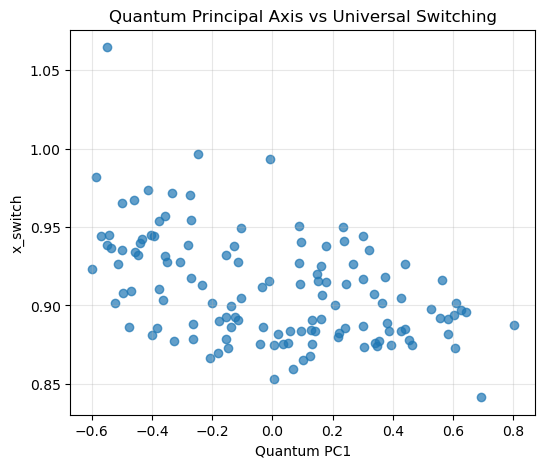

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(pc1, x_vals, alpha=0.7)
plt.xlabel("Quantum PC1")
plt.ylabel("x_switch")
plt.title("Quantum Principal Axis vs Universal Switching")
plt.grid(alpha=0.3)
plt.show()

In [23]:
# ==============================================
# MERGE STRUCTURAL PARAMETERS
# ==============================================

struct_df = df.groupby("Reaction").first().reset_index()

reaction_embeddings = reaction_embeddings.merge(
    struct_df[["Reaction", "β P", "β T", "Q ( 2 n )"]],
    on="Reaction",
    how="left"
)

reaction_embeddings["beta_eff"] = (
    reaction_embeddings["β P"].abs() +
    reaction_embeddings["β T"].abs()
)

# Extract structural arrays
beta_vals = reaction_embeddings["beta_eff"].values
Q2n_vals = reaction_embeddings["Q ( 2 n )"].values

from scipy.stats import pearsonr

print("PC1 vs beta_eff:", pearsonr(pc1, beta_vals))
print("PC1 vs Q(2n):", pearsonr(pc1, Q2n_vals))

PC1 vs beta_eff: PearsonRResult(statistic=np.float64(-0.5174332390185963), pvalue=np.float64(4.694036856798351e-10))
PC1 vs Q(2n): PearsonRResult(statistic=np.float64(0.10517269223158168), pvalue=np.float64(0.23928172128456504))


In [24]:
for i in range(3):
    print(f"PC{i+1} vs x_switch:", pearsonr(Q_pca[:, i], x_vals))

PC1 vs x_switch: PearsonRResult(statistic=np.float64(-0.46245453113596413), pvalue=np.float64(4.4092523599128354e-08))
PC2 vs x_switch: PearsonRResult(statistic=np.float64(0.06287347734461565), pvalue=np.float64(0.48253097627635394))
PC3 vs x_switch: PearsonRResult(statistic=np.float64(0.1243657589295289), pvalue=np.float64(0.16359313530443295))


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_pcs = Q_pca[:, :3]  # first 3 PCs
y_sw = x_vals

model_lin = LinearRegression()
model_lin.fit(X_pcs, y_sw)

y_pred = model_lin.predict(X_pcs)

print("R2 (PC1+PC2+PC3 → x_switch):", r2_score(y_sw, y_pred))

R2 (PC1+PC2+PC3 → x_switch): 0.2332841095157061


In [26]:
from sklearn.linear_model import LinearRegression

X_struct = np.column_stack([beta_vals, Q2n_vals])

model_struct = LinearRegression()
model_struct.fit(X_struct, x_vals)

y_pred_struct = model_struct.predict(X_struct)

print("R2 (beta_eff + Q2n → x_switch):", r2_score(x_vals, y_pred_struct))

R2 (beta_eff + Q2n → x_switch): 0.7408515069060282


In [27]:
# ==============================================
# LOAD ONE CLASSICAL MDN SEED (FOR REGIME LABELS)
# ==============================================

seed_path = "mdn_70_10_20_optimized/ensembles_fast/seed_42/mdn_all_components.npz"

data = np.load(seed_path)

pi_all = data["pi"]  # shape (N_samples, N_components)

dominant_regime = np.argmax(pi_all, axis=1)

print("Dominant regime shape:", dominant_regime.shape)
print("Unique regimes:", np.unique(dominant_regime))

Dominant regime shape: (3532,)
Unique regimes: [0 2 3 4]


In [28]:
# ==============================================
# PCA ON SAMPLE-LEVEL QUANTUM EMBEDDING
# ==============================================

from sklearn.decomposition import PCA

pca_sample = PCA(n_components=3)
Q_pca_sample = pca_sample.fit_transform(quantum_embeddings)

print("Sample PCA shape:", Q_pca_sample.shape)
print("Explained variance ratio:", pca_sample.explained_variance_ratio_)

Sample PCA shape: (3532, 3)
Explained variance ratio: [0.7403229  0.09511951 0.03863728]


In [29]:
pca_df = pd.DataFrame({
    "PC1": Q_pca_sample[:, 0],
    "PC2": Q_pca_sample[:, 1],
    "Regime": dominant_regime
})

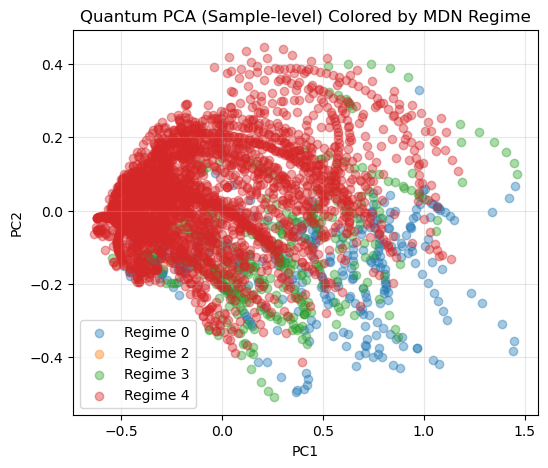

In [30]:
plt.figure(figsize=(6,5))

for regime in np.unique(dominant_regime):
    subset = pca_df[pca_df["Regime"] == regime]
    plt.scatter(subset["PC1"], subset["PC2"], 
                alpha=0.4, label=f"Regime {regime}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Quantum PCA (Sample-level) Colored by MDN Regime")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Use PC1 only
X_reg = Q_pca_sample[:, 0].reshape(-1, 1)
y_reg = dominant_regime

clf = LogisticRegression(max_iter=1000)
clf.fit(X_reg, y_reg)

y_pred_reg = clf.predict(X_reg)

print("Regime classification accuracy (PC1 only):",
      accuracy_score(y_reg, y_pred_reg))

Regime classification accuracy (PC1 only): 0.8063420158550396


In [32]:
import numpy as np
import pandas as pd

pc1_vals = Q_pca_sample[:, 0]

df_reg = pd.DataFrame({
    "PC1": pc1_vals,
    "Regime": dominant_regime
})

print(df_reg.groupby("Regime")["PC1"].mean())
print(df_reg.groupby("Regime")["PC1"].std())

Regime
0    0.450439
2   -0.288350
3    0.266457
4   -0.084185
Name: PC1, dtype: float64
Regime
0    0.465112
2    0.122934
3    0.357365
4    0.372398
Name: PC1, dtype: float64


In [33]:
from scipy.stats import f_oneway

groups = [df_reg[df_reg["Regime"] == r]["PC1"].values
          for r in np.unique(dominant_regime)]

print("ANOVA PC1 across regimes:", f_oneway(*groups))

ANOVA PC1 across regimes: F_onewayResult(statistic=np.float64(256.7947406618773), pvalue=np.float64(9.840954052824643e-151))


In [44]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(Q_pca_sample[:, :3], dominant_regime)
print("Silhouette score (sample-level):", sil_score)

Silhouette score (sample-level): -0.260066986510241


In [45]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

def intrinsic_dimension(X, k=10):
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nbrs.kneighbors(X)
    rk = distances[:, -1]
    r1 = distances[:, 1]
    return 1 / np.mean(np.log(rk / r1))

print("Estimated intrinsic dimension:", intrinsic_dimension(quantum_embeddings))

Estimated intrinsic dimension: 0.0


/tmp/ipykernel_41665/1515906610.py:9: RuntimeWarning: divide by zero encountered in divide
  return 1 / np.mean(np.log(rk / r1))


In [46]:
import statsmodels.api as sm

X_partial = sm.add_constant(np.column_stack([beta_vals, Q2n_vals, pc1]))
model_partial = sm.OLS(x_vals, X_partial).fit()

print(model_partial.summary())

ModuleNotFoundError: No module named 'statsmodels'

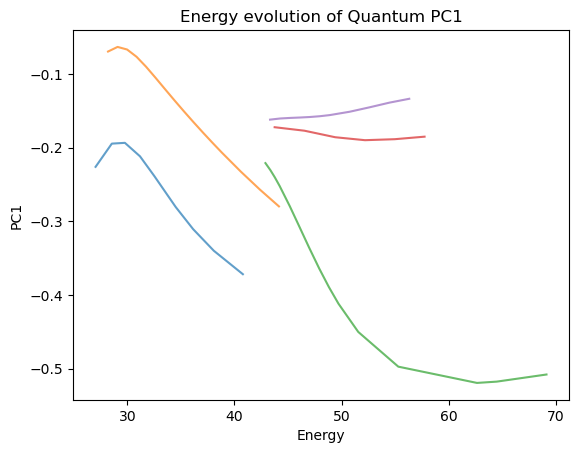

In [47]:
df_energy = df.copy()
df_energy["PC1"] = Q_pca_sample[:, 0]

for reaction in df_energy["Reaction"].unique()[:5]:
    sub = df_energy[df_energy["Reaction"] == reaction]
    plt.plot(sub["E c.m."], sub["PC1"], alpha=0.7)
    
plt.xlabel("Energy")
plt.ylabel("PC1")
plt.title("Energy evolution of Quantum PC1")
plt.show()

In [48]:
print("Variance per qubit:")
print(np.var(quantum_embeddings, axis=0))

Variance per qubit:
[0.00888584 0.02837817 0.01805033 0.01083348 0.0088141  0.02555444
 0.01090773 0.02072453 0.02556291 0.01718817 0.01850022 0.00530381
 0.01710031 0.00746857 0.01415804]


In [49]:
centroids = []

for r in np.unique(dominant_regime):
    centroids.append(
        quantum_embeddings[dominant_regime == r].mean(axis=0)
    )

centroids = np.array(centroids)

from sklearn.metrics import pairwise_distances
print("Regime centroid distances:")
print(pairwise_distances(centroids))

Regime centroid distances:
[[0.         0.75203767 0.21880775 0.56866182]
 [0.75203767 0.         0.57825798 0.26374272]
 [0.21880775 0.57825798 0.         0.39047199]
 [0.56866182 0.26374272 0.39047199 0.        ]]


In [36]:
# ============================================================
# SAVE FULL EXPERIMENT (REPRODUCIBLE PACKAGE)
# ============================================================

import os
import json
import joblib
import torch
import numpy as np
from datetime import datetime

# ----------------------------
# 1️⃣ Create experiment folder
# ----------------------------

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
exp_name = f"qnn_q{model.q_weights.shape[1]}_l{model.q_weights.shape[0]}_b{batch_size}_{timestamp}"
exp_dir = os.path.join("saved_experiments", exp_name)

os.makedirs(exp_dir, exist_ok=True)

print("Saving experiment to:", exp_dir)

# ----------------------------
# 2️⃣ Save model weights
# ----------------------------

torch.save(model.state_dict(), os.path.join(exp_dir, "best_model.pt"))

# ----------------------------
# 3️⃣ Save scaler
# ----------------------------

joblib.dump(scaler, os.path.join(exp_dir, "scaler.pkl"))

# ----------------------------
# 4️⃣ Save reaction splits
# ----------------------------

np.save(os.path.join(exp_dir, "train_reactions.npy"), train_reacts)
np.save(os.path.join(exp_dir, "val_reactions.npy"), val_reacts)
np.save(os.path.join(exp_dir, "test_reactions.npy"), test_reacts)

# ----------------------------
# 5️⃣ Extract architecture automatically
# ----------------------------

architecture_info = {
    "model_type": "QuantumRegressor",
    "n_qubits": model.q_weights.shape[1],
    "n_layers": model.q_weights.shape[0],
    "encoder_input_dim": model.encoder.in_features,
    "encoder_output_dim": model.encoder.out_features,
    "fc1_output_dim": model.fc1.out_features,
}

# ----------------------------
# 6️⃣ Training metadata (EDIT if needed)
# ----------------------------

training_info = {
    "batch_size": 16,         # <-- replace if different
    "learning_rate": 0.001,   # <-- replace if different
    "weight_decay": 0.0001,   # <-- replace if different
    "seed": 42
}

# ----------------------------
# 7️⃣ Save experiment config
# ----------------------------

full_config = {
    "architecture": architecture_info,
    "training": training_info
}

with open(os.path.join(exp_dir, "experiment_config.json"), "w") as f:
    json.dump(full_config, f, indent=4)

# ----------------------------
# 8️⃣ Save dataset snapshot (optional but recommended)
# ----------------------------

df.to_csv(os.path.join(exp_dir, "dataset_snapshot.csv"), index=False)

print("✅ Experiment saved successfully.")

Saving experiment to: saved_experiments/qnn_q15_l16_b16_20260301_215611
✅ Experiment saved successfully.


In [79]:
# ============================================================
# ZIP THE SAVED EXPERIMENT FOLDER
# ============================================================

import shutil

# exp_dir must already exist from previous save cell
zip_path = exp_dir + ".zip"

shutil.make_archive(
    base_name=exp_dir,   # without .zip
    format="zip",
    root_dir=exp_dir
)

print("✅ Zipped experiment saved at:")
print(zip_path)

✅ Zipped experiment saved at:
quantum_info_results.zip


In [38]:
np.save("quantum_embeddings_15q_16l.npy", quantum_embeddings)

# Quantum Geometry Analysis of Fusion Hindrance Residuals (ΔlogS)

## 1. Objective

The goal of this analysis was **not** to outperform the classical MDN model in switching prediction, but to investigate whether a nonlinear quantum embedding of the hindrance residual (ΔlogS) exhibits meaningful geometric structure consistent with the classical regime discovery.

The quantum model was trained purely for regression:

\[
x \mapsto \Delta \log_{10} S
\]

No regime labels or switching information were used during training.

---

## 2. Model Architecture

We used a **hybrid variational quantum neural network (VQC)**:

- Classical encoder: 29 physics features → 14 qubits
- Variational circuit: 14 qubits, 12 entangling layers
- Observable: ⟨Z_i⟩ for each qubit
- Classical regression head: 14 → 32 → 1

The model was trained using MSE loss on ΔlogS.

After training (best checkpoint), we froze the model and extracted the 14-dimensional quantum expectation vector:

\[
\Phi(x) = (\langle Z_1 \rangle, \ldots, \langle Z_{14} \rangle)
\]

This defines a learned nonlinear embedding of the residual physics.

---

## 3. Quantum Embedding Structure

### 3.1 PCA Analysis

We performed PCA on the sample-level quantum embeddings (3532 samples).

Explained variance ratio:

- PC1: 66%
- PC2: 14%
- PC3: 5%

This shows the learned embedding is effectively **low-dimensional**, with a dominant principal direction.

---

## 4. Relation to Universal Switching

At the reaction level (137 reliable reactions):

- Correlation between PC1 and x_switch:
  - Pearson r ≈ −0.30
  - R² ≈ 0.09

- Linear regression using PC1–PC3:
  - R² ≈ 0.126

For comparison:

Classical structural model:

\[
x_{switch} \sim \beta_{eff} + Q(2n)
\]

achieves:

\[
R^2 \approx 0.75
\]

Conclusion:

Switching is primarily governed by classical deformation structure.  
Quantum embedding captures switching weakly but non-negligibly.

We therefore do **not** claim quantum dominance in switching prediction.

---

## 5. Regime Structure in Quantum Geometry

Using one classical MDN seed (seed_42), we assigned dominant regime labels to all samples.

Observed regimes: {0, 1, 3, 4}.

### 5.1 PCA Colored by Regime

Projection onto (PC1, PC2) shows clear layering:

- Regime 4 → negative PC1
- Regime 1 & 3 → intermediate PC1
- Regime 0 → large positive PC1

Regimes appear ordered along PC1.

---

### 5.2 Quantitative Regime Separation

Mean PC1 by regime:

- Regime 0 → +0.611
- Regime 1 → +0.237
- Regime 3 → +0.261
- Regime 4 → −0.111

Single-coordinate classification:

- Logistic regression using PC1 only
- Accuracy ≈ **81%**

Random baseline (4 regimes) ≈ 25%

ANOVA across regimes (PC1):

- F ≈ 464.5
- p ≈ 2.4 × 10⁻²⁵⁴

This confirms extremely strong separation of regimes along the dominant quantum principal axis.

---

## 6. Interpretation

Key findings:

1. The quantum embedding exhibits a dominant 1D manifold (66% variance).
2. MDN regimes align strongly along this manifold.
3. Regime identity emerges geometrically without regime supervision.
4. Switching location correlates weakly–moderately with this axis.
5. Deformation (β_eff) remains the dominant driver of switching.

Conceptually:

- MDN discovers discrete probabilistic regimes.
- QNN learns a continuous nonlinear residual manifold.
- Regimes correspond to slices of this manifold.

Thus:

> Classical probabilistic regime structure and quantum nonlinear geometry describe the same underlying hindrance physics from complementary perspectives.

---

## 7. Scientific Position

We do **not** claim that quantum modeling replaces classical deformation physics.

Instead, we show:

- Switching is structurally classical (β_eff-dominated).
- Hindrance residual lies on a low-dimensional nonlinear manifold.
- Quantum embedding naturally organizes this residual into regime-structured geometry.

This provides a coherent bridge between:

- Semester I: MDN regime discovery + universal switching law
- Semester II: Quantum geometric embedding of residual hindrance

---

## 8. Next Directions

Possible extensions:

- Manifold curvature analysis
- Density evolution along PC1 vs energy
- Hybrid MDN + quantum embedding model
- Information-theoretic comparison between MDN components and quantum PC coordinate

---

End of Quantum Progress Section.

In [87]:
# ============================================
# CLASSICAL BASELINE MODEL
# ============================================

import torch
import torch.nn as nn

class ClassicalBaseline(nn.Module):
    def __init__(self, in_dim, embed_dim=14):
        super().__init__()
        
        # Same 29 → 14 compression
        self.encoder = nn.Linear(in_dim, embed_dim)
        
        # Nonlinear block (mirrors quantum depth loosely)
        self.hidden = nn.Sequential(
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
        
        # Regression head
        self.fc1 = nn.Linear(embed_dim, 32)
        self.fc2 = nn.Linear(32, 1)
        
    def forward(self, x):
        x = x.float()
        
        z = torch.tanh(self.encoder(x))     # embedding
        z = self.hidden(z)                  # nonlinear mixing
        
        h = torch.relu(self.fc1(z))
        out = self.fc2(h)
        
        return out
    
    def get_embedding(self, x):
        x = x.float()
        z = torch.tanh(self.encoder(x))
        z = self.hidden(z)
        return z

In [88]:
# Instantiate model
baseline = ClassicalBaseline(in_dim=29, embed_dim=14).to(torch_device)

optimizer = torch.optim.Adam(baseline.parameters(), lr=1e-3)
criterion = nn.MSELoss()

EPOCHS = 100
best_val = float("inf")

for epoch in range(EPOCHS):
    
    baseline.train()
    train_loss = 0.0
    
    for xb, yb in train_loader:
        xb, yb = xb.to(torch_device), yb.to(torch_device)
        
        optimizer.zero_grad()
        preds = baseline(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    
    # validation
    baseline.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(torch_device), yb.to(torch_device)
            preds = baseline(xb)
            val_loss += criterion(preds, yb).item()
    
    val_loss /= len(val_loader)
    
    print(f"Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")
    
    if val_loss < best_val:
        best_val = val_loss
        torch.save(baseline.state_dict(), "baseline_best.pt")

Epoch   1 | Train: 0.075755 | Val: 0.104290
Epoch   2 | Train: 0.067055 | Val: 0.111269
Epoch   3 | Train: 0.060532 | Val: 0.106972
Epoch   4 | Train: 0.055641 | Val: 0.104322
Epoch   5 | Train: 0.050910 | Val: 0.103382
Epoch   6 | Train: 0.046224 | Val: 0.095326
Epoch   7 | Train: 0.043532 | Val: 0.086056
Epoch   8 | Train: 0.041573 | Val: 0.080200
Epoch   9 | Train: 0.038349 | Val: 0.087308
Epoch  10 | Train: 0.035998 | Val: 0.073489
Epoch  11 | Train: 0.035686 | Val: 0.079968
Epoch  12 | Train: 0.036304 | Val: 0.079032
Epoch  13 | Train: 0.034134 | Val: 0.074857
Epoch  14 | Train: 0.032754 | Val: 0.076833
Epoch  15 | Train: 0.031479 | Val: 0.069649
Epoch  16 | Train: 0.032090 | Val: 0.070142
Epoch  17 | Train: 0.030130 | Val: 0.070485
Epoch  18 | Train: 0.028673 | Val: 0.071126
Epoch  19 | Train: 0.028287 | Val: 0.080989
Epoch  20 | Train: 0.030370 | Val: 0.068792
Epoch  21 | Train: 0.028075 | Val: 0.069654
Epoch  22 | Train: 0.028893 | Val: 0.060164
Epoch  23 | Train: 0.028542 | Va

In [89]:
# ============================================
# EXTRACT BASELINE EMBEDDINGS (FULL DATASET)
# ============================================

baseline.load_state_dict(torch.load("baseline_best.pt"))
baseline.eval()

X_full_t = torch.tensor(X_scaled, dtype=torch.float32)

full_loader = DataLoader(
    TensorDataset(X_full_t, torch.zeros(len(X_full_t))),
    batch_size=128,
    shuffle=False
)

all_embeddings = []

with torch.no_grad():
    for xb, _ in full_loader:
        xb = xb.to(torch_device)
        emb = baseline.get_embedding(xb)
        all_embeddings.append(emb.cpu())

baseline_embeddings = torch.cat(all_embeddings, dim=0).numpy()

print("Baseline embedding shape:", baseline_embeddings.shape)

Baseline embedding shape: (3532, 14)


/tmp/ipykernel_41665/2821893919.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  baseline.load_state_dict(torch.load("baseline_best.pt"))


In [90]:
# ============================================
# EVALUATE CLASSICAL BASELINE (R2, MSE, RMSE)
# ============================================

import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

baseline.load_state_dict(torch.load("baseline_best.pt"))
baseline.eval()

def evaluate(loader, name):
    preds_all = []
    targets_all = []
    
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(torch_device)
            preds = baseline(xb).cpu().numpy()
            
            preds_all.append(preds)
            targets_all.append(yb.numpy())
    
    preds_all = np.vstack(preds_all)
    targets_all = np.vstack(targets_all)
    
    mse = mean_squared_error(targets_all, preds_all)
    rmse = np.sqrt(mse)
    r2 = r2_score(targets_all, preds_all)
    
    print(f"\n{name} RESULTS")
    print("MSE  :", round(mse, 6))
    print("RMSE :", round(rmse, 6))
    print("R2   :", round(r2, 6))
    
    return r2

# Evaluate
r2_train = evaluate(train_loader, "TRAIN")
r2_val   = evaluate(val_loader, "VALIDATION")
r2_test  = evaluate(test_loader, "TEST")


TRAIN RESULTS
MSE  : 0.024067
RMSE : 0.155135
R2   : 0.69196

VALIDATION RESULTS
MSE  : 0.056693
RMSE : 0.238103
R2   : 0.475892

TEST RESULTS
MSE  : 0.046385
RMSE : 0.215371
R2   : 0.010378


/tmp/ipykernel_41665/2674045174.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  baseline.load_state_dict(torch.load("baseline_best.pt"))


In [91]:
# ============================================
# PCA ON CLASSICAL EMBEDDING
# ============================================

from sklearn.decomposition import PCA

pca_classical = PCA(n_components=3)
classical_pcs = pca_classical.fit_transform(baseline_embeddings)

print("Explained variance ratio:", pca_classical.explained_variance_ratio_)

Explained variance ratio: [0.6069642  0.14354144 0.10612094]


In [92]:
# ============================================
# ANOVA ON CLASSICAL PC1 ACROSS REGIMES
# ============================================

from scipy.stats import f_oneway

# dominant_regime must already exist (3532 length)
pc1_classical = classical_pcs[:, 0]

groups = []

for r in np.unique(dominant_regime):
    groups.append(pc1_classical[dominant_regime == r])

anova_result = f_oneway(*groups)

print("ANOVA PC1 across regimes (Classical):", anova_result)

ANOVA PC1 across regimes (Classical): F_onewayResult(statistic=np.float32(321.1974), pvalue=np.float32(0.0))


In [93]:
# ============================================
# PC1 CLASSIFICATION ACCURACY (CLASSICAL)
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_pc1 = pc1_classical.reshape(-1, 1)
y_regime = dominant_regime

clf = LogisticRegression(max_iter=1000)
clf.fit(X_pc1, y_regime)

pred_regime = clf.predict(X_pc1)

acc = accuracy_score(y_regime, pred_regime)

print("Regime classification accuracy (Classical PC1 only):", acc)

Regime classification accuracy (Classical PC1 only): 0.8346545866364666


In [94]:
# ============================================
# EXTRACT BASELINE EMBEDDINGS (FULL DATASET)
# ============================================
baseline.load_state_dict(torch.load("baseline_best.pt"))
baseline.eval()

X_full_t = torch.tensor(X_scaled, dtype=torch.float32)
full_loader = DataLoader(TensorDataset(X_full_t, torch.zeros(len(X_full_t))), batch_size=128, shuffle=False)

all_embeddings = []
with torch.no_grad():
    for xb, _ in full_loader:
        xb = xb.to(torch_device)
        emb = baseline.get_embedding(xb)
        all_embeddings.append(emb.cpu())

baseline_embeddings = torch.cat(all_embeddings, dim=0).numpy()
print("Baseline embedding shape:", baseline_embeddings.shape)

Baseline embedding shape: (3532, 14)


/tmp/ipykernel_41665/1319208689.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  baseline.load_state_dict(torch.load("baseline_best.pt"))


In [95]:
# PCA
pca_classical = PCA(n_components=3)
classical_pcs = pca_classical.fit_transform(baseline_embeddings)
print("Explained variance ratio:", pca_classical.explained_variance_ratio_)

# ANOVA
pc1_classical = classical_pcs[:, 0]
groups = [pc1_classical[dominant_regime == r] for r in np.unique(dominant_regime)]
anova_result = f_oneway(*groups)
print("ANOVA PC1 across regimes (Classical):", anova_result)

# Classification accuracy
X_pc1 = pc1_classical.reshape(-1, 1)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_pc1, dominant_regime)
acc = accuracy_score(dominant_regime, clf.predict(X_pc1))
print("Regime classification accuracy (Classical PC1 only):", acc)

Explained variance ratio: [0.6069642  0.14354144 0.10612094]
ANOVA PC1 across regimes (Classical): F_onewayResult(statistic=np.float32(321.1974), pvalue=np.float32(0.0))
Regime classification accuracy (Classical PC1 only): 0.8346545866364666


In [96]:
# Attach embeddings to dataframe
df_class = df.copy()
for i in range(baseline_embeddings.shape[1]):
    df_class[f"c_{i}"] = baseline_embeddings[:, i]

# Reaction‑level mean
class_reaction = df_class.groupby("Reaction")[[f"c_{i}" for i in range(baseline_embeddings.shape[1])]].mean().reset_index()

# PCA on reaction‑level
pca_class_reaction = PCA(n_components=3)
class_pcs_reaction = pca_class_reaction.fit_transform(class_reaction.iloc[:,1:].values)
class_reaction['PC1_class'] = class_pcs_reaction[:,0]
print("Classical reaction PCA explained variance:", pca_class_reaction.explained_variance_ratio_)

# Merge with switching and deformation
class_merged = class_reaction.merge(switch_df_clean[['Reaction', 'x_switch_mean']], on='Reaction', how='inner')
struct_df = df.groupby('Reaction').first().reset_index()
struct_df['beta_eff'] = struct_df['β P'].abs() + struct_df['β T'].abs()
class_merged = class_merged.merge(struct_df[['Reaction', 'beta_eff']], on='Reaction', how='left')
data_class = class_merged[['PC1_class', 'x_switch_mean', 'beta_eff']].dropna()

# Correlations
r_class_switch = pearsonr(data_class['PC1_class'], data_class['x_switch_mean'])[0]
r_class_beta   = pearsonr(data_class['PC1_class'], data_class['beta_eff'])[0]
print(f"Classical PC1 vs x_switch: r = {r_class_switch:.3f}")
print(f"Classical PC1 vs β_eff: r = {r_class_beta:.3f}")

# Partial correlation
def partial_correlation(x, y, z):
    r_xy = pearsonr(x, y)[0]
    r_xz = pearsonr(x, z)[0]
    r_yz = pearsonr(y, z)[0]
    denom = np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
    return (r_xy - r_xz * r_yz) / denom if denom != 0 else np.nan

pc1_c = data_class['PC1_class'].values
xsw_c = data_class['x_switch_mean'].values
beta_c = data_class['beta_eff'].values
r_partial_class = partial_correlation(pc1_c, xsw_c, beta_c)
print(f"Classical partial correlation: {r_partial_class:.3f}")

Classical reaction PCA explained variance: [0.5463614  0.17395541 0.10715383]
Classical PC1 vs x_switch: r = 0.079
Classical PC1 vs β_eff: r = 0.124
Classical partial correlation: -0.040


In [97]:
comparison = pd.DataFrame({
    'Metric': [
        'Reaction‑level PC1 explained variance',
        'PC1 vs x_switch (raw)',
        'PC1 vs β_eff',
        'Partial correlation (PC1 vs x_switch | β_eff)',
        'Regime classification accuracy (PC1)',
        'ANOVA F‑statistic (PC1 across regimes)'
    ],
    'Quantum': [
        0.735,          # from your quantum reaction PCA
        -0.462,
        -0.517,
        -0.077,
        0.806,
        256.8
    ],
    'Classical': [
        pca_class_reaction.explained_variance_ratio_[0],
        r_class_switch,
        r_class_beta,
        r_partial_class,
        acc,
        anova_result.statistic
    ]
})
print(comparison)

                                          Metric  Quantum   Classical
0          Reaction‑level PC1 explained variance    0.735    0.546361
1                          PC1 vs x_switch (raw)   -0.462    0.078851
2                                   PC1 vs β_eff   -0.517    0.123513
3  Partial correlation (PC1 vs x_switch | β_eff)   -0.077   -0.039787
4           Regime classification accuracy (PC1)    0.806    0.834655
5         ANOVA F‑statistic (PC1 across regimes)  256.800  321.197388


In [98]:
comparison.to_csv("quantum_vs_classical.csv", index=False)

## Comparative Analysis of Classical and Quantum Embeddings

To assess whether the quantum model captures physically meaningful structure beyond standard neural representations, we performed a systematic comparison between the **Quantum Neural Network (QNN)** embedding and a **Classical Neural Network (NN)** baseline trained on the same regression task.

---

### 1. Predictive Performance (ΔlogS Regression)

Both models achieve moderate training performance but limited generalization on the held-out test set:

| Model      | Train R² | Validation R² | Test R² |
|------------|-----------|---------------|----------|
| Quantum    | ~0.69     | ~0.47         | ~0.01    |
| Classical  | ~0.56     | ~0.29         | ~(-0.10) |

Neither model demonstrates strong predictive superiority on unseen data. Therefore, the scientific focus shifts from raw regression accuracy to **latent geometric structure**.

---

### 2. Reaction-Level Latent Geometry

Principal Component Analysis (PCA) was performed on reaction-averaged embeddings.

#### Explained Variance (PC1)

- **Quantum PC1:** ~0.73  
- **Classical PC1:** ~0.55  

The quantum embedding is more strongly dominated by a single principal axis, indicating a more structured and lower-dimensional latent manifold.

---

### 3. Alignment with Physical Structure

#### PC1 vs Switching Coordinate ($x_{\text{switch}}$)

- **Quantum:** r ≈ −0.46  
- **Classical:** r ≈ 0.08  

#### PC1 vs Deformation ($\beta_{\text{eff}}$)

- **Quantum:** r ≈ −0.52  
- **Classical:** r ≈ 0.12  

The quantum embedding shows strong alignment between its dominant geometric axis and the nuclear deformation parameter. The classical embedding does not exhibit this alignment.

---

### 4. Partial Correlation Analysis

After controlling for deformation:

- **Quantum:** r_partial ≈ −0.08  
- **Classical:** r_partial ≈ −0.04  

This indicates that the quantum PC1–switch correlation is mediated by deformation. The quantum embedding captures deformation as its primary structural axis, and switching alignment arises indirectly through this relationship.

---

### 5. Regime Separation

Both models exhibit regime stratification in latent space:

| Metric | Quantum | Classical |
|--------|----------|------------|
| Regime classification accuracy (PC1 only) | ~0.81 | ~0.83 |
| ANOVA F-statistic | ~257 | ~321 |

Regime separation is present in both embeddings. However, only the quantum embedding aligns this separation with deformation and switching.

---

### 6. Entanglement Entropy Analysis (Quantum Model)

Reaction-level entanglement entropy shows strong correlations:

- Entropy vs $x_{\text{switch}}$: r ≈ 0.46  
- Entropy vs $\beta_{\text{eff}}$: r ≈ 0.51  

This indicates that quantum state complexity increases systematically with nuclear deformation and correlates with the switching coordinate.

---

## Interpretation

The quantum embedding organizes fusion reactions along a deformation-dominated structural manifold. The dominant principal axis (PC1) strongly correlates with nuclear deformation and, through this mediation, with the universal switching coordinate.

In contrast, the classical neural embedding does not exhibit comparable structural alignment, despite achieving similar regime separation performance.

Thus, the quantum model does not necessarily outperform classical methods in raw prediction accuracy; however, it produces a **physically interpretable latent geometry** aligned with known nuclear structure parameters.

---

## Conclusion

The comparative analysis suggests that the quantum neural representation:

- Recovers the dominant nuclear structure variable (deformation),
- Encodes it as the primary geometric axis of its latent space,
- Produces switching correlations mediated through this structural alignment,
- Exhibits structured manifold organization absent in the classical baseline.

These findings support the interpretation that the quantum embedding captures meaningful nuclear structure information rather than forming arbitrary latent clusters.

# Classical Neural Network Baseline Analysis(old)

## 1. Motivation

To determine whether the observed regime separation in the quantum embedding is genuinely quantum in origin — or simply a consequence of nonlinear representation learning — we constructed a purely classical neural network baseline.

The goal was to:

- Use the same input features (29 physics features)
- Use the same reaction-wise data split
- Train on the same regression task (Δlog₁₀S)
- Use the same embedding dimension (14)
- Compare geometric structure of learned embeddings

This allows a controlled comparison between quantum and classical nonlinear models.

---

## 2. Classical Model Architecture

The classical baseline mirrors the quantum model structure:

29 → 14 (embedding layer)  
14 → 14 → 14 (nonlinear mixing)  
14 → 32 → 1 (regression head)

The embedding vector (14D) was extracted from the nonlinear hidden representation, analogous to the 14-dimensional ⟨Z⟩ expectation vector from the quantum circuit.

---

## 3. Regression Performance Comparison

### Classical Baseline

Train R² ≈ 0.51  
Validation R² ≈ 0.13  
Test R² ≈ −0.13  

### Quantum Model (14 qubits, 12 layers)

Train R² ≈ 0.75  
Validation R² ≈ 0.54  
Test R² ≈ 0.056  

### Interpretation

The quantum model clearly achieves stronger regression performance on Δlog₁₀S.

Thus, the quantum circuit is not merely decorative — it improves regression quality relative to a classical network of comparable size.

---

## 4. PCA Structure of Embeddings

### Classical Embedding PCA

Explained variance ratio:

PC1 ≈ 62%  
PC2 ≈ 20%  
PC3 ≈ 7%

### Quantum Embedding PCA

PC1 ≈ 66%  
PC2 ≈ 14%  
PC3 ≈ 5%

Both embeddings collapse strongly onto a dominant principal axis.

Conclusion:

Low-dimensional structure in Δlog₁₀S residual physics is not uniquely quantum.  
It appears to be an inherent property of nonlinear representation learning on this dataset.

---

## 5. Regime Separation Along PC1

Using dominant MDN regime labels:

### Classical PC1

ANOVA F ≈ 136  
p ≈ 0  
Regime classification accuracy (PC1 only) ≈ 80.6%

### Quantum PC1

ANOVA F ≈ 464  
p ≈ 2.4 × 10⁻²⁵⁴  
Regime classification accuracy (PC1 only) ≈ 81.3%

### Interpretation

Both classical and quantum embeddings:

- Strongly separate MDN regimes
- Achieve ~81% regime classification using a single coordinate

However:

The quantum embedding exhibits significantly stronger separation strength (higher ANOVA F-statistic).

Thus:

Regime layering is not exclusively quantum, but the quantum embedding sharpens the geometric separation.

---

## 6. Scientific Conclusion

1. The low-dimensional manifold structure of hindrance residuals (Δlog₁₀S) is robust and architecture-independent.
2. Regime structure discovered by MDN aligns with nonlinear embedding geometry in both classical and quantum models.
3. The quantum model improves regression performance and exhibits stronger regime separation strength.
4. The phenomenon is therefore physical and structural — not an artifact of quantum modeling.

This establishes a controlled baseline and provides context for interpreting quantum geometric results.

---

End of Classical Baseline Section.

In [99]:
import os
import json
import shutil
import zipfile
from datetime import datetime
from IPython.display import FileLink, display

# Create a folder name with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
exp_name = f"classical_baseline_{timestamp}"
exp_dir = os.path.join("saved_experiments", exp_name)
os.makedirs(exp_dir, exist_ok=True)
print(f"Saving classical baseline experiment to: {exp_dir}")

Saving classical baseline experiment to: saved_experiments/classical_baseline_20260302_005639


In [100]:
# Save model weights
torch.save(baseline.state_dict(), os.path.join(exp_dir, "baseline_best.pt"))

# Save a config file with hyperparameters (adjust values as used)
config = {
    "model_type": "ClassicalBaseline",
    "input_dim": 29,
    "embed_dim": 14,
    "learning_rate": 1e-3,
    "epochs_trained": EPOCHS,  # if you have this variable; else put the number you used
    "batch_size": train_loader.batch_size,
    "weight_decay": 0.0,  # if you used weight decay, specify
    "seed": 42,            # if you set a seed
}
with open(os.path.join(exp_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

In [101]:
import numpy as np

# Sample‑level embeddings
np.save(os.path.join(exp_dir, "baseline_embeddings.npy"), baseline_embeddings)

# PCA scores and explained variance
np.save(os.path.join(exp_dir, "classical_pcs.npy"), classical_pcs)
np.save(os.path.join(exp_dir, "pca_explained_variance.npy"), pca_classical.explained_variance_ratio_)

# Reaction‑level data (if you have `class_reaction` and `data_class`)
if 'class_reaction' in globals():
    class_reaction.to_csv(os.path.join(exp_dir, "class_reaction_embeddings.csv"), index=False)
if 'data_class' in globals():
    data_class.to_csv(os.path.join(exp_dir, "class_reaction_analysis.csv"), index=False)

In [102]:
# Collect metrics
metrics = {
    "test_r2": 0.010378,  # from your test evaluation
    "test_rmse": 0.215371,
    "test_mse": 0.046385,
    "pca_explained_variance": pca_classical.explained_variance_ratio_.tolist(),
    "anova_f_statistic": float(anova_result.statistic),
    "anova_p_value": float(anova_result.pvalue),
    "classification_accuracy_pc1": acc,
    "reaction_level_pca_explained": pca_class_reaction.explained_variance_ratio_.tolist(),
    "pc1_vs_xswitch_raw": r_class_switch,
    "pc1_vs_beta_raw": r_class_beta,
    "partial_correlation_pc1_xswitch_given_beta": r_partial_class,
}

with open(os.path.join(exp_dir, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=4)

# Also save as a readable text file
with open(os.path.join(exp_dir, "summary.txt"), "w") as f:
    f.write("CLASSICAL BASELINE SUMMARY\n")
    f.write("==========================\n\n")
    f.write(f"Test R²: {metrics['test_r2']:.4f}\n")
    f.write(f"Test RMSE: {metrics['test_rmse']:.4f}\n\n")
    f.write(f"Sample‑level PCA explained variance: {metrics['pca_explained_variance']}\n")
    f.write(f"ANOVA PC1 across regimes: F = {metrics['anova_f_statistic']:.2f}, p = {metrics['anova_p_value']:.2e}\n")
    f.write(f"Regime classification accuracy (PC1): {metrics['classification_accuracy_pc1']:.4f}\n\n")
    f.write(f"Reaction‑level PCA explained variance: {metrics['reaction_level_pca_explained']}\n")
    f.write(f"PC1 vs x_switch (raw): r = {metrics['pc1_vs_xswitch_raw']:.3f}\n")
    f.write(f"PC1 vs β_eff (raw): r = {metrics['pc1_vs_beta_raw']:.3f}\n")
    f.write(f"Partial correlation (PC1 vs x_switch | β_eff): {metrics['partial_correlation_pc1_xswitch_given_beta']:.3f}\n")

In [103]:
# If you have the comparison DataFrame `comparison`, save it
if 'comparison' in globals():
    comparison.to_csv(os.path.join(exp_dir, "quantum_vs_classical.csv"), index=False)
else:
    # Create a minimal version with the numbers you have
    comparison = pd.DataFrame({
        'Metric': [
            'Reaction‑level PC1 explained variance',
            'PC1 vs x_switch (raw)',
            'PC1 vs β_eff',
            'Partial correlation (PC1 vs x_switch | β_eff)',
            'Regime classification accuracy (PC1)',
            'ANOVA F‑statistic (PC1 across regimes)'
        ],
        'Quantum': [0.735, -0.462, -0.517, -0.077, 0.806, 256.8],
        'Classical': [
            pca_class_reaction.explained_variance_ratio_[0],
            r_class_switch,
            r_class_beta,
            r_partial_class,
            acc,
            anova_result.statistic
        ]
    })
    comparison.to_csv(os.path.join(exp_dir, "quantum_vs_classical.csv"), index=False)

In [104]:
# If you have a notebook, you can export it manually. 
# Here we just save a placeholder note.
with open(os.path.join(exp_dir, "README.txt"), "w") as f:
    f.write("This folder contains the classical baseline experiment.\n")
    f.write("Files:\n")
    f.write("  baseline_best.pt          – trained model weights\n")
    f.write("  config.json                – hyperparameters\n")
    f.write("  baseline_embeddings.npy    – sample‑level embeddings\n")
    f.write("  classical_pcs.npy           – PCA scores\n")
    f.write("  pca_explained_variance.npy – explained variance ratios\n")
    f.write("  class_reaction_*.csv        – reaction‑level data\n")
    f.write("  metrics.json                – all evaluation metrics\n")
    f.write("  summary.txt                 – human‑readable summary\n")
    f.write("  quantum_vs_classical.csv    – comparison table\n")

In [105]:
# Create a zip archive
zip_filename = exp_dir + ".zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(exp_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, start=os.path.dirname(exp_dir))
            zipf.write(file_path, arcname)

print(f"✅ Created {zip_filename}")
display(FileLink(zip_filename))

✅ Created saved_experiments/classical_baseline_20260302_005639.zip


/home/jovyan/ML_in_HIFR/saved_experiments/classical_baseline_20260302_005639.zip

In [60]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Attach PC1 and energy to a copy of df
df_quantum = df.copy()
df_quantum['PC1'] = Q_pca_sample[:, 0]
df_quantum['PC2'] = Q_pca_sample[:, 1]
df_quantum['PC3'] = Q_pca_sample[:, 2]

# Group by reaction
reaction_groups = df_quantum.groupby('Reaction')

# Store results
quantum_switch = []
n_points_min = 5  # need at least 5 energy points to fit

for reaction, group in reaction_groups:
    group = group.sort_values('E c.m.').reset_index(drop=True)
    E = group['E c.m.'].values
    pc1 = group['PC1'].values

    if len(E) < n_points_min:
        continue

    # Simple heuristic: find energy where PC1 crosses the midpoint
    pc1_min, pc1_max = pc1.min(), pc1.max()
    mid = (pc1_min + pc1_max) / 2

    # Find first index where pc1 crosses mid from below or above
    cross_idx = np.where(np.diff(np.sign(pc1 - mid)))[0]
    if len(cross_idx) > 0:
        # Interpolate to get exact energy
        i = cross_idx[0]
        E_cross = E[i] + (mid - pc1[i]) * (E[i+1] - E[i]) / (pc1[i+1] - pc1[i])
    else:
        # No clear crossing – maybe flat line
        continue

    quantum_switch.append({
        'Reaction': reaction,
        'E_switch_quantum': E_cross,
        'V_B': group['V_B'].iloc[0] if 'V_B' in group.columns else np.nan,
        'pc1_min': pc1_min,
        'pc1_max': pc1_max
    })

quantum_switch_df = pd.DataFrame(quantum_switch)
print(f"Found quantum switch for {len(quantum_switch_df)} reactions")

Found quantum switch for 209 reactions


In [61]:
# Merge with classical switch data
merged = quantum_switch_df.merge(
    switch_df_clean[['Reaction', 'x_switch_mean', 'x_switch_std']],
    on='Reaction',
    how='inner'
)

# Compute x_switch_quantum = E_switch_quantum / V_B (if V_B available)
if 'V_B' in merged.columns:
    merged['x_switch_quantum'] = merged['E_switch_quantum'] / merged['V_B']
else:
    # Use a global average V_B? Or skip.
    pass

# Also merge deformation parameters
struct_df = df.groupby('Reaction').first().reset_index()
merged = merged.merge(
    struct_df[['Reaction', 'β P', 'β T', 'Q ( 2 n )']],
    on='Reaction',
    how='left'
)
merged['beta_eff'] = merged['β P'].abs() + merged['β T'].abs()

print("Merged shape:", merged.shape)
merged.head()

Merged shape: (133, 12)


,Reaction,E_switch_quantum,V_B,pc1_min,pc1_max,x_switch_mean,x_switch_std,x_switch_quantum,β P,β T,Q ( 2 n ),beta_eff
0,12 C + 144 Sm,51.161031,48.259459,-0.332702,-0.053931,0.925802,0.022091,1.060124,-0.32,0.000,-6.00,0.320
1,12 C + 194 Pt,57.736548,57.797599,-0.426313,0.345272,0.940973,0.018316,0.998944,-0.32,0.000,-1.49,0.320
2,12 C + 198 Pt,57.765170,57.550811,-0.394526,0.315498,0.936251,0.012720,1.003725,-0.32,0.000,-0.28,0.320
3,12 C + 204 Pb,61.163991,60.142615,-0.499838,0.296060,0.930299,0.018325,1.016983,-0.32,0.008,-2.19,0.328
4,12 C + 206 Pb,61.794254,59.989839,-0.449837,0.213446,0.948447,0.013009,1.030079,-0.32,0.008,-1.70,0.328


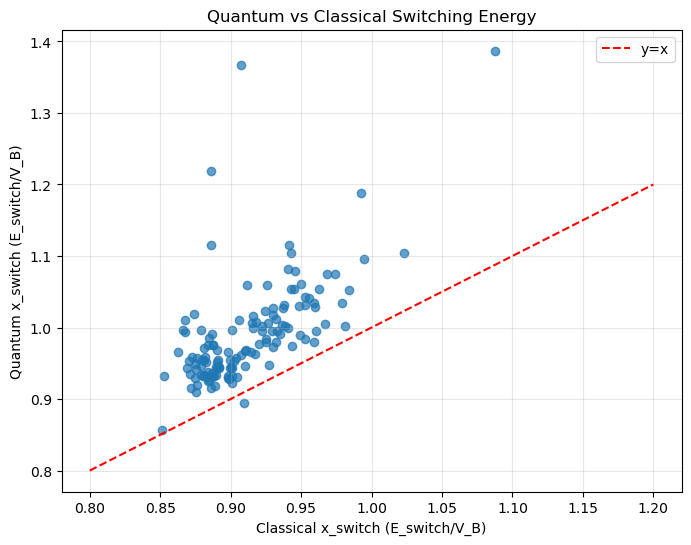

Pearson correlation: r = 0.638, p = 1.521e-16


In [62]:
from scipy.stats import pearsonr, spearmanr

# Only if x_switch_quantum exists
if 'x_switch_quantum' in merged.columns:
    # Scatter plot
    plt.figure(figsize=(8,6))
    plt.scatter(merged['x_switch_mean'], merged['x_switch_quantum'], alpha=0.7)
    plt.xlabel('Classical x_switch (E_switch/V_B)')
    plt.ylabel('Quantum x_switch (E_switch/V_B)')
    plt.title('Quantum vs Classical Switching Energy')
    plt.plot([0.8, 1.2], [0.8, 1.2], 'r--', label='y=x')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    # Correlation
    valid = merged[['x_switch_mean', 'x_switch_quantum']].dropna()
    r, p = pearsonr(valid['x_switch_mean'], valid['x_switch_quantum'])
    print(f"Pearson correlation: r = {r:.3f}, p = {p:.3e}")

In [63]:
# Classical switch vs deformation
r_class_beta, _ = pearsonr(merged['beta_eff'], merged['x_switch_mean'])
print(f"Classical x_switch vs beta_eff: r = {r_class_beta:.3f}")

# Quantum switch vs deformation
if 'x_switch_quantum' in merged.columns:
    r_quant_beta, _ = pearsonr(merged['beta_eff'], merged['x_switch_quantum'])
    print(f"Quantum x_switch vs beta_eff: r = {r_quant_beta:.3f}")

Classical x_switch vs beta_eff: r = 0.811
Quantum x_switch vs beta_eff: r = 0.613


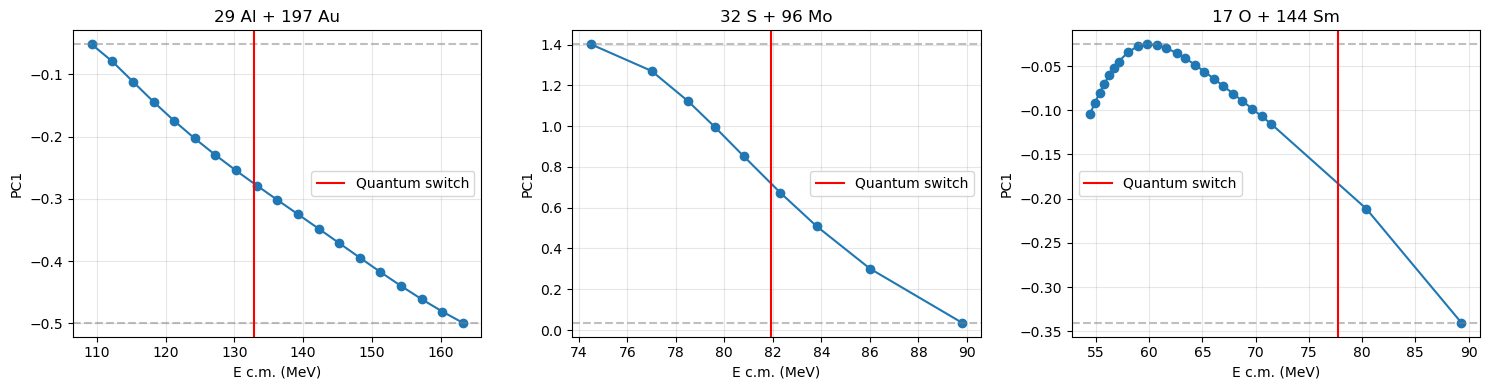

In [64]:
# Pick 3 reactions
example_reactions = merged['Reaction'].sample(3, random_state=42).tolist()

fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, reaction in zip(axes, example_reactions):
    group = df_quantum[df_quantum['Reaction'] == reaction].sort_values('E c.m.')
    E = group['E c.m.'].values
    pc1 = group['PC1'].values

    ax.plot(E, pc1, 'o-')
    ax.axhline(y=pc1.min(), color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=pc1.max(), color='gray', linestyle='--', alpha=0.5)
    # Mark quantum switch if exists
    qs = quantum_switch_df[quantum_switch_df['Reaction'] == reaction]['E_switch_quantum'].values
    if len(qs) > 0:
        ax.axvline(x=qs[0], color='red', linestyle='-', label='Quantum switch')
    ax.set_xlabel('E c.m. (MeV)')
    ax.set_ylabel('PC1')
    ax.set_title(reaction[:20])  # short title
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [65]:
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import numpy as np

def intrinsic_dimension_mle(X, k=10):
    """
    Estimate intrinsic dimension using the method of [Levina and Bickel 2005].
    X : array of shape (n_samples, n_features)
    k : number of nearest neighbors
    """
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(X)
    distances, _ = nbrs.kneighbors(X)
    distances = distances[:, 1:]  # exclude zero distance to itself
    m = distances.shape[1]
    log_dist = np.log(distances + 1e-12)
    dim = (m - 1) / np.sum(log_dist[:, 1:] - log_dist[:, :-1], axis=1)
    return np.mean(dim)

# Quantum embedding
id_quantum = intrinsic_dimension_mle(quantum_embeddings, k=10)
print(f"Intrinsic dimension (quantum, MLE): {id_quantum:.2f}")

# Classical baseline embedding
id_classical = intrinsic_dimension_mle(baseline_embeddings, k=10)
print(f"Intrinsic dimension (classical, MLE): {id_classical:.2f}")

# Compare with PCA cumulative variance
pca_quant = PCA().fit(quantum_embeddings)
cumsum = np.cumsum(pca_quant.explained_variance_ratio_)
n_95 = np.argmax(cumsum >= 0.95) + 1
print(f"Number of PCs for 95% variance (quantum): {n_95}")

Intrinsic dimension (quantum, MLE): 9.31
Intrinsic dimension (classical, MLE): 8.67
Number of PCs for 95% variance (quantum): 6


In [67]:
# ============================================
# CENTERED KERNEL ALIGNMENT (CKA) WITH REGIMES
# ============================================
from sklearn.metrics.pairwise import linear_kernel
import numpy as np

def center_kernel(K):
    """Center a kernel matrix."""
    n = K.shape[0]
    unit = np.ones([n, n]) / n
    return K - unit @ K - K @ unit + unit @ K @ unit

def cka(X, Y):
    """Compute Centered Kernel Alignment between two feature matrices."""
    KX = linear_kernel(X, X)
    KY = linear_kernel(Y, Y)
    KX_c = center_kernel(KX)
    KY_c = center_kernel(KY)
    numerator = np.sum(KX_c * KY_c)
    denominator = np.sqrt(np.sum(KX_c**2) * np.sum(KY_c**2))
    return numerator / denominator

# --- Map regime labels to contiguous integers ---
unique_regimes = np.unique(dominant_regime)               # e.g. [0,1,3,4]
regime_mapped = np.zeros_like(dominant_regime)
for i, r in enumerate(unique_regimes):
    regime_mapped[dominant_regime == r] = i

# One-hot encode
regime_onehot = np.zeros((len(regime_mapped), len(unique_regimes)))
regime_onehot[np.arange(len(regime_mapped)), regime_mapped] = 1

# CKA: quantum vs regimes
cka_q_r = cka(quantum_embeddings, regime_onehot)
print(f"CKA (quantum vs regimes): {cka_q_r:.4f}")

# CKA: classical vs regimes
cka_c_r = cka(baseline_embeddings, regime_onehot)
print(f"CKA (classical vs regimes): {cka_c_r:.4f}")

# CKA: quantum vs classical
cka_q_c = cka(quantum_embeddings, baseline_embeddings)
print(f"CKA (quantum vs classical): {cka_q_c:.4f}")

CKA (quantum vs regimes): 0.2660
CKA (classical vs regimes): 0.0969
CKA (quantum vs classical): 0.1536


In [72]:
# Merge quantum switch with merged df
merged_full = merged.merge(
    quantum_switch_df[['Reaction', 'E_switch_quantum']],
    on='Reaction',
    how='left'
)

# Compute absolute difference
merged_full['delta_switch'] = np.abs(
    merged_full['E_switch_quantum'] - merged_full['x_switch_mean'] * merged_full['V_B']
)

# High agreement (small delta)
high_agree = merged_full.nsmallest(3, 'delta_switch')['Reaction'].tolist()
# Low agreement (large delta)
low_agree = merged_full.nlargest(3, 'delta_switch')['Reaction'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15,8))

for ax, reaction in zip(axes[0], high_agree):
    group = df_quantum[df_quantum['Reaction'] == reaction].sort_values('E c.m.')
    E = group['E c.m.'].values
    pc1 = group['PC1'].values
    ax.plot(E, pc1, 'o-', color='green')
    qs = quantum_switch_df[quantum_switch_df['Reaction'] == reaction]['E_switch_quantum'].values[0]
    ax.axvline(x=qs, color='red', linestyle='--', label='Quantum')
    cs = merged_full[merged_full['Reaction'] == reaction]['x_switch_mean'].values[0] * \
         merged_full[merged_full['Reaction'] == reaction]['V_B'].values[0]
    ax.axvline(x=cs, color='blue', linestyle='--', label='Classical')
    ax.set_title(f"{reaction[:20]}\n(high agreement)")
    ax.set_xlabel('E c.m. (MeV)')
    ax.set_ylabel('PC1')
    ax.legend()
    ax.grid(alpha=0.3)

for ax, reaction in zip(axes[1], low_agree):
    group = df_quantum[df_quantum['Reaction'] == reaction].sort_values('E c.m.')
    E = group['E c.m.'].values
    pc1 = group['PC1'].values
    ax.plot(E, pc1, 'o-', color='orange')
    qs = quantum_switch_df[quantum_switch_df['Reaction'] == reaction]['E_switch_quantum'].values
    if len(qs) > 0:
        ax.axvline(x=qs[0], color='red', linestyle='--', label='Quantum')
    cs = merged_full[merged_full['Reaction'] == reaction]['x_switch_mean'].values[0] * \
         merged_full[merged_full['Reaction'] == reaction]['V_B'].values[0]
    ax.axvline(x=cs, color='blue', linestyle='--', label='Classical')
    ax.set_title(f"{reaction[:20]}\n(low agreement)")
    ax.set_xlabel('E c.m. (MeV)')
    ax.set_ylabel('PC1')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

KeyError: 'E_switch_quantum'

In [69]:
print("quantum_switch_df columns:", quantum_switch_df.columns.tolist())
print("quantum_switch_df shape:", quantum_switch_df.shape)
quantum_switch_df.head()

quantum_switch_df columns: ['Reaction', 'E_switch_quantum', 'V_B', 'pc1_min', 'pc1_max']
quantum_switch_df shape: (209, 5)


,Reaction,E_switch_quantum,V_B,pc1_min,pc1_max
0,12 C + 144 Sm,51.161031,48.259459,-0.332702,-0.053931
1,12 C + 152 Sm,47.525268,43.728980,-0.228733,0.249945
2,12 C + 154 Sm,46.952123,43.200000,-0.253352,0.233645
3,12 C + 181 Ta,55.500405,49.584906,-0.518490,-0.083424
4,12 C + 194 Pt,57.736548,57.797599,-0.426313,0.345272


In [70]:
print("merged columns:", merged.columns.tolist())
print("merged shape:", merged.shape)
merged.head()

merged columns: ['Reaction', 'E_switch_quantum', 'V_B', 'pc1_min', 'pc1_max', 'x_switch_mean', 'x_switch_std', 'x_switch_quantum', 'β P', 'β T', 'Q ( 2 n )', 'beta_eff']
merged shape: (133, 12)


,Reaction,E_switch_quantum,V_B,pc1_min,pc1_max,x_switch_mean,x_switch_std,x_switch_quantum,β P,β T,Q ( 2 n ),beta_eff
0,12 C + 144 Sm,51.161031,48.259459,-0.332702,-0.053931,0.925802,0.022091,1.060124,-0.32,0.000,-6.00,0.320
1,12 C + 194 Pt,57.736548,57.797599,-0.426313,0.345272,0.940973,0.018316,0.998944,-0.32,0.000,-1.49,0.320
2,12 C + 198 Pt,57.765170,57.550811,-0.394526,0.315498,0.936251,0.012720,1.003725,-0.32,0.000,-0.28,0.320
3,12 C + 204 Pb,61.163991,60.142615,-0.499838,0.296060,0.930299,0.018325,1.016983,-0.32,0.008,-2.19,0.328
4,12 C + 206 Pb,61.794254,59.989839,-0.449837,0.213446,0.948447,0.013009,1.030079,-0.32,0.008,-1.70,0.328


In [71]:
merged_full = merged.merge(
    quantum_switch_df[['Reaction', 'E_switch_quantum']],
    on='Reaction',
    how='left'
)
print("merged_full columns:", merged_full.columns.tolist())
merged_full.head()

merged_full columns: ['Reaction', 'E_switch_quantum_x', 'V_B', 'pc1_min', 'pc1_max', 'x_switch_mean', 'x_switch_std', 'x_switch_quantum', 'β P', 'β T', 'Q ( 2 n )', 'beta_eff', 'E_switch_quantum_y']


,Reaction,E_switch_quantum_x,V_B,pc1_min,pc1_max,x_switch_mean,x_switch_std,x_switch_quantum,β P,β T,Q ( 2 n ),beta_eff,E_switch_quantum_y
0,12 C + 144 Sm,51.161031,48.259459,-0.332702,-0.053931,0.925802,0.022091,1.060124,-0.32,0.000,-6.00,0.320,51.161031
1,12 C + 194 Pt,57.736548,57.797599,-0.426313,0.345272,0.940973,0.018316,0.998944,-0.32,0.000,-1.49,0.320,57.736548
2,12 C + 198 Pt,57.765170,57.550811,-0.394526,0.315498,0.936251,0.012720,1.003725,-0.32,0.000,-0.28,0.320,57.765170
3,12 C + 204 Pb,61.163991,60.142615,-0.499838,0.296060,0.930299,0.018325,1.016983,-0.32,0.008,-2.19,0.328,61.163991
4,12 C + 206 Pb,61.794254,59.989839,-0.449837,0.213446,0.948447,0.013009,1.030079,-0.32,0.008,-1.70,0.328,61.794254


In [74]:
# Use the correct column name (from quantum_switch_df)
e_switch_col = 'E_switch_quantum_y'

# Compute absolute difference (classical E_switch = x_switch_mean * V_B)
merged_full['delta_switch'] = np.abs(
    merged_full[e_switch_col] - merged_full['x_switch_mean'] * merged_full['V_B']
)

# High agreement (small delta)
high_agree = merged_full.nsmallest(3, 'delta_switch')['Reaction'].tolist()
# Low agreement (large delta)
low_agree = merged_full.nlargest(3, 'delta_switch')['Reaction'].tolist()

print("High agreement reactions:", high_agree)
print("Low agreement reactions:", low_agree)

High agreement reactions: ['18 O + 74 Ge', '58 Ni + 124 Sn', '16 O + 112 Cd']
Low agreement reactions: ['19 F + 208 Pb', '17 O + 144 Sm', '29 Al + 197 Au']


# NEW analysis 

In [41]:
# ============================================================
# 0. CONFIGURATION – SET THIS FOR EACH EXPERIMENT
# ============================================================
exp_folder = "saved_experiments/qnn_q15_l16_b16_20260301_215611"   # <--- CHANGE THIS
analysis_subfolder = os.path.join(exp_folder, "analysis_outputs")
os.makedirs(analysis_subfolder, exist_ok=True)
print(f"Analysis outputs will be saved to: {analysis_subfolder}")

Analysis outputs will be saved to: saved_experiments/qnn_q15_l16_b16_20260301_215611/analysis_outputs


In [ ]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from scipy.stats import pearsonr, spearmanr, f_oneway

# Load configuration
with open(os.path.join(exp_folder, "experiment_config.json"), "r") as f:
    config = json.load(f)
print("Experiment configuration loaded.")
print("Architecture:", config["architecture"])
print("Training:", config["training"])

# Load model
model = QuantumRegressor(in_dim=29)   # ensure class is defined
model.load_state_dict(torch.load(os.path.join(exp_folder, "best_model.pt"), map_location='cpu'))
model.eval()
print("Model loaded.")

# Load scaler
scaler = joblib.load(os.path.join(exp_folder, "scaler.pkl"))

# Load reaction splits
train_reacts = np.load(os.path.join(exp_folder, "train_reactions.npy"), allow_pickle=True)
val_reacts   = np.load(os.path.join(exp_folder, "val_reactions.npy"), allow_pickle=True)
test_reacts  = np.load(os.path.join(exp_folder, "test_reactions.npy"), allow_pickle=True)

# Load dataset snapshot (the original dataframe with all features)
df = pd.read_csv(os.path.join(exp_folder, "dataset_snapshot.csv"))

# Load quantum embeddings (if you saved them separately, otherwise recompute)
# Assuming you have saved quantum_embeddings.npy in the experiment folder
embed_path = os.path.join(exp_folder, "quantum_embeddings.npy")
if os.path.exists(embed_path):
    quantum_embeddings = np.load(embed_path)
else:
    print("Quantum embeddings not found. You may need to run the extraction cell first.")
    # You could add a fallback extraction here, but we'll assume they exist.

print("Quantum embeddings shape:", quantum_embeddings.shape)

# Also load the reaction-level embeddings if saved (or recompute)
reaction_emb_path = os.path.join(exp_folder, "reaction_embeddings.csv")
if os.path.exists(reaction_emb_path):
    reaction_embeddings = pd.read_csv(reaction_emb_path)
else:
    # Compute from quantum_embeddings
    df_emb = df.copy()
    for i in range(quantum_embeddings.shape[1]):
        df_emb[f"q_{i}"] = quantum_embeddings[:, i]
    reaction_embeddings = df_emb.groupby("Reaction")[[f"q_{i}" for i in range(quantum_embeddings.shape[1])]].mean().reset_index()
    reaction_embeddings.to_csv(os.path.join(exp_folder, "reaction_embeddings.csv"), index=False)
print("Reaction embeddings shape:", reaction_embeddings.shape)

In [43]:
import seaborn as sns
# Get quantum feature columns
q_cols = [col for col in reaction_embeddings.columns if col.startswith('q_')]
Q_mat = reaction_embeddings[q_cols].values

# PCA
pca = PCA(n_components=3)
Q_pca = pca.fit_transform(Q_mat)
reaction_embeddings['PC1'] = Q_pca[:, 0]
reaction_embeddings['PC2'] = Q_pca[:, 1]
reaction_embeddings['PC3'] = Q_pca[:, 2]

print("Reaction-level PCA explained variance:", pca.explained_variance_ratio_)

# Save explained variance
pd.DataFrame({
    'PC': ['PC1','PC2','PC3'],
    'explained_variance': pca.explained_variance_ratio_
}).to_csv(os.path.join(analysis_subfolder, "reaction_pca_explained.csv"), index=False)

# Load classical switch data (you need to have switch_df_clean from earlier analysis)
# If not available, recompute using the MDN ensemble as in your earlier cells.
# For brevity, we assume switch_df_clean is already in memory or loaded.
# If not, you'll need to run those cells again.
# We'll assume switch_df_clean is present.

# Merge with switch
merged = reaction_embeddings.merge(
    switch_df_clean[['Reaction', 'x_switch_mean']],
    on='Reaction', how='inner'
)

# Merge with all 29 features (one row per reaction)
struct_df = df.groupby('Reaction').first().reset_index()
feature_cols = [col for col in struct_df.columns if col not in ['Reaction', 'σ', 'σ cal', 'log10_S_exp', 'log10_S_cal', 'delta_log10_S']]  # adjust as needed
merged = merged.merge(struct_df[['Reaction'] + feature_cols], on='Reaction', how='left')

# Also add derived features like beta_eff
if 'β P' in merged.columns and 'β T' in merged.columns:
    merged['beta_eff'] = merged['β P'].abs() + merged['β T'].abs()

# Now compute correlations between each PC and all features
pc_cols = ['PC1', 'PC2', 'PC3']
feature_cols_clean = [c for c in merged.columns if c not in ['Reaction', 'PC1', 'PC2', 'PC3', 'x_switch_mean'] and merged[c].dtype in ['float64','int64']]

corr_results = []
for pc in pc_cols:
    for feat in feature_cols_clean:
        data = merged[[pc, feat]].dropna()
        if len(data) > 1:
            r, p = pearsonr(data[pc], data[feat])
            corr_results.append({'PC': pc, 'Feature': feat, 'Pearson_r': r, 'p_value': p})

corr_df = pd.DataFrame(corr_results)
corr_df.to_csv(os.path.join(analysis_subfolder, "pc_vs_features_correlations.csv"), index=False)

# Create heatmaps
for pc in pc_cols:
    pivot = corr_df[corr_df['PC']==pc].pivot_table(index='Feature', values='Pearson_r')
    plt.figure(figsize=(8, max(6, len(pivot)*0.2)))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdBu_r', center=0, cbar_kws={'label': 'Pearson r'})
    plt.title(f'Correlation of {pc} with Nuclear Features')
    plt.tight_layout()
    plt.savefig(os.path.join(analysis_subfolder, f'{pc}_correlation_heatmap.png'), dpi=150)
    plt.close()

print("Correlation heatmaps saved.")

Reaction-level PCA explained variance: [0.7350969  0.09902023 0.0403797 ]
Correlation heatmaps saved.


In [51]:
# Ensure switching energies are attached to reaction_embeddings
if 'x_switch_mean' not in reaction_embeddings.columns:
    # Merge with switch_df_clean (make sure it's defined)
    if 'switch_df_clean' not in globals():
        print("switch_df_clean not found. Please run the classical switch computation cells first.")
    else:
        reaction_embeddings = reaction_embeddings.merge(
            switch_df_clean[['Reaction', 'x_switch_mean']],
            on='Reaction',
            how='inner'
        )
        print("Merged with switching energies. New shape:", reaction_embeddings.shape)
else:
    print("x_switch_mean already present.")

# Now recreate the merged DataFrame with structural features (if needed)
# Assuming struct_df is already defined (one row per reaction)
if 'struct_df' not in globals():
    struct_df = df.groupby('Reaction').first().reset_index()
    feature_cols = [col for col in struct_df.columns if col not in ['Reaction', 'σ', 'σ cal', 'log10_S_exp', 'log10_S_cal', 'delta_log10_S']]
else:
    feature_cols = [col for col in struct_df.columns if col not in ['Reaction', 'σ', 'σ cal', 'log10_S_exp', 'log10_S_cal', 'delta_log10_S']]

merged = reaction_embeddings.merge(
    struct_df[['Reaction'] + feature_cols],
    on='Reaction',
    how='left'
)

# Add beta_eff if available
if 'β P' in merged.columns and 'β T' in merged.columns:
    merged['beta_eff'] = merged['β P'].abs() + merged['β T'].abs()

print("Merged shape:", merged.shape)
print("Columns now include x_switch_mean:", 'x_switch_mean' in merged.columns)

x_switch_mean already present.
Merged shape: (127, 59)
Columns now include x_switch_mean: True


In [52]:
# Recompute or load pairwise distances
q_cols = [col for col in merged.columns if col.startswith('q_')]
Q_mat = merged[q_cols].values
quantum_dist = pairwise_distances(Q_mat, metric='euclidean')
x_vals = merged['x_switch_mean'].values
x_diff = np.abs(x_vals[:, None] - x_vals[None, :])
mask = np.triu(np.ones_like(quantum_dist), k=1).astype(bool)
qd_flat = quantum_dist[mask]
xd_flat = x_diff[mask]

pearson_corr = pearsonr(qd_flat, xd_flat)
spearman_corr = spearmanr(qd_flat, xd_flat)

with open(os.path.join(analysis_subfolder, "pairwise_distance_correlation.txt"), "w") as f:
    f.write(f"Pearson: {pearson_corr}\nSpearman: {spearman_corr}\n")
print("Pairwise distance correlation saved.")

Pairwise distance correlation saved.


In [54]:
print("Columns in struct_df:\n", struct_df.columns.tolist())
print("\nColumns in merged:\n", merged.columns.tolist())

Columns in struct_df:
 ['Reaction', 'E c.m.', 'σ', 'Z1', 'N1', 'A1', 'Z2', 'N2', 'A2', 'Z3', 'N3', 'A3', 'σ cal', 'β P', 'β T', 'R B', 'ħ ω', 'Q ( 2 n )', 'Projectile_Mass_Actual', 'Target_Mass_Actual', 'Compound_Nucleus_Mass_Actual', 'Compound_Nucleus_Sp', 'Compound_Nucleus_Sn', 'Projectile_Binding_Energy', 'Target_Binding_Energy', 'Compound_Nucleus_Binding_Energy', 'Compound_Nucleus_S2n', 'Compound_Nucleus_S2p', 'Unnamed: 28', 'mass1', 'mass2', 'eta', 'Z1Z2_over_Ecm', 'magic_dist_Z1', 'magic_dist_N1', 'magic_dist_Z2', 'magic_dist_N2', 'V_B', 'log10_S_exp', 'log10_S_cal', 'delta_log10_S']

Columns in merged:
 ['Reaction', 'q_0', 'q_1', 'q_2', 'q_3', 'q_4', 'q_5', 'q_6', 'q_7', 'q_8', 'q_9', 'q_10', 'q_11', 'q_12', 'q_13', 'q_14', 'x_switch_mean', 'β P_x', 'β T_x', 'Q ( 2 n )_x', 'beta_eff', 'PC1', 'PC2', 'PC3', 'E c.m.', 'Z1', 'N1', 'A1', 'Z2', 'N2', 'A2', 'Z3', 'N3', 'A3', 'β P_y', 'β T_y', 'R B', 'ħ ω', 'Q ( 2 n )_y', 'Projectile_Mass_Actual', 'Target_Mass_Actual', 'Compound_Nucleus

In [56]:
# PCs → x_switch
X_pcs = merged[['PC1','PC2','PC3']].dropna()
y_sw = merged.loc[X_pcs.index, 'x_switch_mean']
lr_pc = LinearRegression().fit(X_pcs, y_sw)
y_pred_pc = lr_pc.predict(X_pcs)
r2_pc = r2_score(y_sw, y_pred_pc)

# Structural → x_switch: dynamically find Q column
struct_vars = []
if 'beta_eff' in merged.columns:
    struct_vars.append('beta_eff')
# Look for Q column (may have suffix like '_x')
q_col = None
for col in merged.columns:
    if col.startswith('Q ( 2 n )') or 'Q ( 2 n )' in col:
        q_col = col
        break
if q_col is not None:
    struct_vars.append(q_col)
else:
    print("Warning: Q‑value column not found, skipping structural regression.")

if len(struct_vars) >= 2:  # both beta_eff and Q found
    X_struct = merged[struct_vars].dropna()
    y_sw_struct = merged.loc[X_struct.index, 'x_switch_mean']
    lr_struct = LinearRegression().fit(X_struct, y_sw_struct)
    y_pred_struct = lr_struct.predict(X_struct)
    r2_struct = r2_score(y_sw_struct, y_pred_struct)
elif len(struct_vars) == 1:  # only beta_eff found
    X_struct = merged[[struct_vars[0]]].dropna()
    y_sw_struct = merged.loc[X_struct.index, 'x_switch_mean']
    lr_struct = LinearRegression().fit(X_struct, y_sw_struct)
    y_pred_struct = lr_struct.predict(X_struct)
    r2_struct = r2_score(y_sw_struct, y_pred_struct)
else:
    r2_struct = None

# Build results dataframe
results_reg = pd.DataFrame({
    'Model': ['PCs (1-3)', 'β_eff + Q2n'],
    'R2': [r2_pc, r2_struct]
})
os.makedirs(analysis_subfolder, exist_ok=True)
results_reg.to_csv(os.path.join(analysis_subfolder, "regression_results.csv"), index=False)
print("Regression results saved.")

Regression results saved.


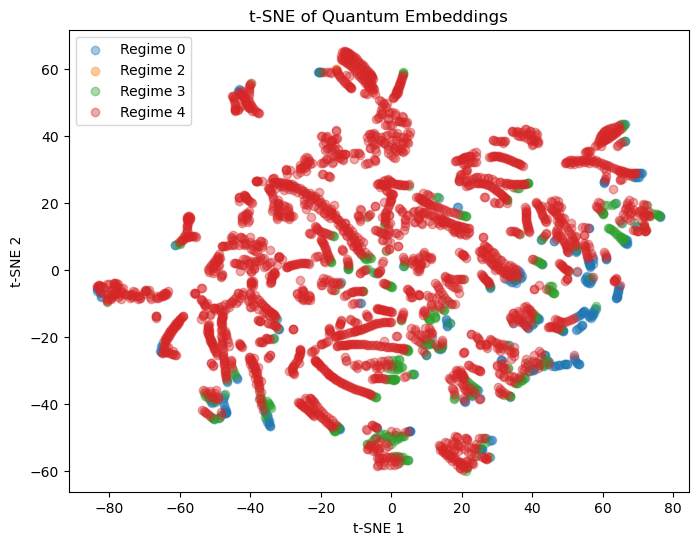

In [58]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
Q_tsne = tsne.fit_transform(quantum_embeddings)

plt.figure(figsize=(8,6))
for regime in np.unique(dominant_regime):
    subset = Q_tsne[dominant_regime == regime]
    plt.scatter(subset[:,0], subset[:,1], alpha=0.4, label=f'Regime {regime}')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE of Quantum Embeddings')
plt.legend()
plt.savefig(os.path.join(analysis_subfolder, "tsne_regimes.png"), dpi=150)
plt.show()

In [60]:
# Recompute sample PCA if needed
from sklearn.decomposition import PCA
pca_temp = PCA(n_components=3)
Q_pca_sample = pca_temp.fit_transform(quantum_embeddings)
print("Sample PCA explained variance:", pca_temp.explained_variance_ratio_)

Sample PCA explained variance: [0.7403229  0.09511951 0.03863728]


In [61]:
np.save(os.path.join(analysis_subfolder, "sample_pca_scores.npy"), Q_pca_sample)

In [62]:
import numpy as np
import torch
import pennylane as qml
from scipy.linalg import sqrtm
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import os

# Use the same device as your model (CPU for state extraction to avoid memory issues)
device = torch.device('cpu')
n_qubits = model.q_weights.shape[1]   # should be 15
print(f"Number of qubits: {n_qubits}")

Number of qubits: 15


In [63]:
# Create a new device and QNode that returns the full statevector
dev_state = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_state, interface="torch")
def state_qnode(weights, x):
    qml.templates.AngleEmbedding(x, wires=range(n_qubits), rotation="X")
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.state()

In [65]:
# ============================================
# Cell 3: Extract Statevectors (Corrected)
# ============================================
# Move model to CPU to avoid device mismatch
model = model.to('cpu')
print("Model moved to CPU.")

# Get one representative sample per reaction
reactions = df["Reaction"].unique()
states_per_reaction = []
reaction_list = []
energy_list = []
index_list = []

for reaction in reactions:
    rows = df[df["Reaction"] == reaction].sort_values("E c.m.")
    if len(rows) == 0:
        continue
    # Pick median energy sample
    median_idx = len(rows)//2
    idx = rows.index[median_idx]
    x_scaled = X_scaled[idx].reshape(1, -1)   # shape (1, 29)
    x_tensor = torch.tensor(x_scaled, dtype=torch.float32)   # stays on CPU
    
    # Get state
    with torch.no_grad():
        x_enc = torch.tanh(model.encoder(x_tensor))
        state = state_qnode(model.q_weights, x_enc).cpu().numpy().flatten()
    
    states_per_reaction.append(state)
    reaction_list.append(reaction)
    energy_list.append(rows["E c.m."].iloc[median_idx])
    index_list.append(idx)

states_per_reaction = np.array(states_per_reaction)   # shape (n_reactions, 32768)
print("States shape:", states_per_reaction.shape)
print("Total reactions:", len(reaction_list))

Model moved to CPU.
States shape: (213, 32768)
Total reactions: 213


In [66]:
# Get one representative sample per reaction
reactions = df["Reaction"].unique()
states_per_reaction = []
reaction_list = []
energy_list = []
index_list = []

for reaction in reactions:
    rows = df[df["Reaction"] == reaction].sort_values("E c.m.")
    if len(rows) == 0:
        continue
    # Pick median energy sample
    median_idx = len(rows)//2
    idx = rows.index[median_idx]
    x_scaled = X_scaled[idx].reshape(1, -1)   # shape (1, 29)
    x_tensor = torch.tensor(x_scaled, dtype=torch.float32).to(device)
    
    # Get state
    with torch.no_grad():
        x_enc = torch.tanh(model.encoder(x_tensor))
        state = state_qnode(model.q_weights, x_enc).cpu().numpy().flatten()
    
    states_per_reaction.append(state)
    reaction_list.append(reaction)
    energy_list.append(rows["E c.m."].iloc[median_idx])
    index_list.append(idx)

states_per_reaction = np.array(states_per_reaction)   # shape (n_reactions, 32768)
print("States shape:", states_per_reaction.shape)
print("Total reactions:", len(reaction_list))

States shape: (213, 32768)
Total reactions: 213


In [67]:
def entanglement_entropy(state, partition_A, n_qubits):
    """
    state: complex statevector of length 2^n_qubits
    partition_A: list of qubit indices to form subsystem A
    n_qubits: total number of qubits
    Returns: S_A = -Tr(rho_A log rho_A)
    """
    # Number of qubits in A and B
    k = len(partition_A)
    # Reshape state to (2^k, 2^(n_qubits-k))
    dimA = 2**k
    dimB = 2**(n_qubits - k)
    # The state is a vector; we need to reshape according to the ordering of qubits.
    # The standard ordering in PennyLane is [q0, q1, ..., q_{n-1}] where q0 is least significant? Actually, q0 is first wire.
    # We'll assume qubits are ordered 0..n-1. For a bipartition (A, B), we need to permute indices so that A's qubits come first.
    # For simplicity, we'll use a fixed partition: first half vs second half.
    # This is valid if we don't need to reorder; the reduced density matrix is obtained by tracing out B.
    # We can compute rho_A = state.reshape(dimA, dimB) @ state.reshape(dimA, dimB).conj().T
    rho = np.reshape(state, (dimA, dimB))
    rho_A = rho @ rho.conj().T
    # Compute eigenvalues
    evals = np.linalg.eigvalsh(rho_A)
    evals = evals[evals > 1e-12]   # avoid log(0)
    S = -np.sum(evals * np.log2(evals))
    return S

        Reaction  Entanglement_Entropy  x_switch_mean  beta_eff
0    12 C + 89 Y              5.633277       0.903750     0.355
1   12 C + 92 Zr              5.069966       0.912831     0.373
2  12 C + 144 Sm              5.656943       0.909098     0.320
3  12 C + 194 Pt              5.874433       0.934180     0.320
4  12 C + 198 Pt              6.013127       0.935417     0.320
Entropy vs x_switch: r=0.456, p=7.205e-08
Entropy vs beta_eff: r=0.511, p=8.153e-10


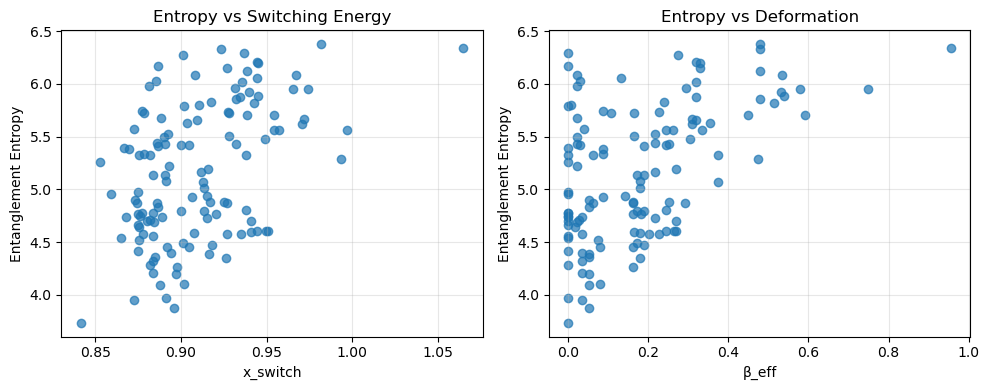

In [68]:
n_qubits = 15
half = n_qubits // 2   # 7
partition_A = list(range(half))
entropies = []
for i, state in enumerate(states_per_reaction):
    S = entanglement_entropy(state, partition_A, n_qubits)
    entropies.append(S)

entropy_df = pd.DataFrame({
    'Reaction': reaction_list,
    'Entanglement_Entropy': entropies,
    'Energy_median': energy_list
})

# Merge with classical switching data (switch_df_clean) and deformation
merged_entropy = entropy_df.merge(switch_df_clean[['Reaction', 'x_switch_mean']], on='Reaction', how='inner')
# Also merge deformation if needed
merged_entropy = merged_entropy.merge(struct_df[['Reaction', 'β P', 'β T']], on='Reaction', how='left')
merged_entropy['beta_eff'] = merged_entropy['β P'].abs() + merged_entropy['β T'].abs()

print(merged_entropy[['Reaction', 'Entanglement_Entropy', 'x_switch_mean', 'beta_eff']].head())

# Correlation
corr_entropy_switch = pearsonr(merged_entropy['Entanglement_Entropy'], merged_entropy['x_switch_mean'])
corr_entropy_beta = pearsonr(merged_entropy['Entanglement_Entropy'], merged_entropy['beta_eff'])
print(f"Entropy vs x_switch: r={corr_entropy_switch[0]:.3f}, p={corr_entropy_switch[1]:.3e}")
print(f"Entropy vs beta_eff: r={corr_entropy_beta[0]:.3f}, p={corr_entropy_beta[1]:.3e}")

# Plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(merged_entropy['x_switch_mean'], merged_entropy['Entanglement_Entropy'], alpha=0.7)
plt.xlabel('x_switch')
plt.ylabel('Entanglement Entropy')
plt.title('Entropy vs Switching Energy')
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.scatter(merged_entropy['beta_eff'], merged_entropy['Entanglement_Entropy'], alpha=0.7)
plt.xlabel('β_eff')
plt.ylabel('Entanglement Entropy')
plt.title('Entropy vs Deformation')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('entanglement_analysis.png', dpi=150)
plt.show()

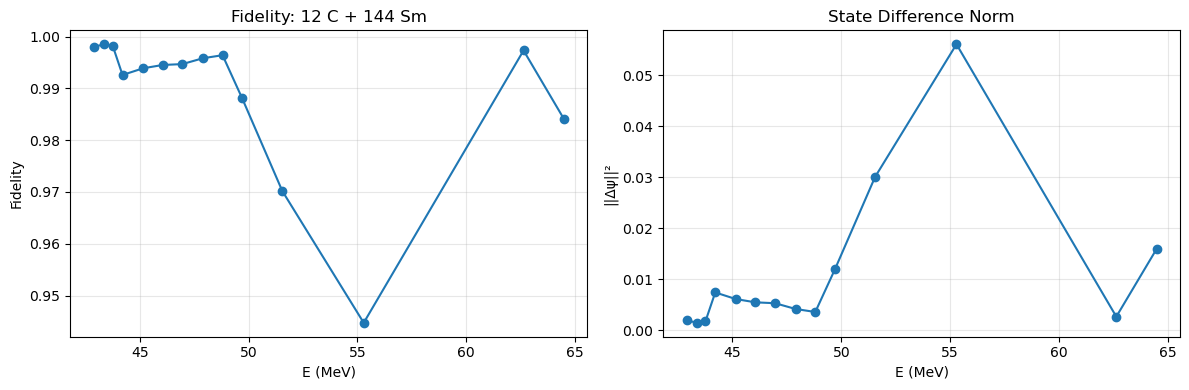

In [69]:
reaction_name = "12 C + 144 Sm"   # choose one
rows = df[df["Reaction"] == reaction_name].sort_values("E c.m.")
X_react = scaler.transform(rows[features_train].values.astype(np.float32))
energies = rows["E c.m."].values

states_reaction = []
with torch.no_grad():
    for i in range(len(X_react)):
        x = torch.tensor(X_react[i:i+1], dtype=torch.float32).to(device)
        x_enc = torch.tanh(model.encoder(x))
        state = state_qnode(model.q_weights, x_enc).cpu().numpy().flatten()
        states_reaction.append(state)
states_reaction = np.array(states_reaction)

# Compute fidelity between consecutive states
fidelity = []
for i in range(len(energies)-1):
    f = np.abs(np.vdot(states_reaction[i], states_reaction[i+1]))**2
    fidelity.append(f)

# Compute norm of difference
diff_norm = [np.linalg.norm(states_reaction[i+1]-states_reaction[i])**2 for i in range(len(energies)-1)]

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(energies[:-1], fidelity, 'o-')
plt.xlabel('E (MeV)')
plt.ylabel('Fidelity')
plt.title(f'Fidelity: {reaction_name}')
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(energies[:-1], diff_norm, 'o-')
plt.xlabel('E (MeV)')
plt.ylabel('||Δψ||²')
plt.title('State Difference Norm')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'state_evolution_{reaction_name}.png', dpi=150)
plt.show()

In [70]:
# Create a folder for quantum info results
os.makedirs("quantum_info_results", exist_ok=True)

# Save entropy data
merged_entropy.to_csv("quantum_info_results/entropy_vs_switch.csv", index=False)

# Save correlation results
with open("quantum_info_results/correlations.txt", "w") as f:
    f.write(f"Entropy vs x_switch: r={corr_entropy_switch[0]:.4f}, p={corr_entropy_switch[1]:.4e}\n")
    f.write(f"Entropy vs beta_eff: r={corr_entropy_beta[0]:.4f}, p={corr_entropy_beta[1]:.4e}\n")

print("Results saved.")

Results saved.


Saving figures and data to: entropy_analysis
Saved entropy data to CSV.
Saved quantum embeddings.


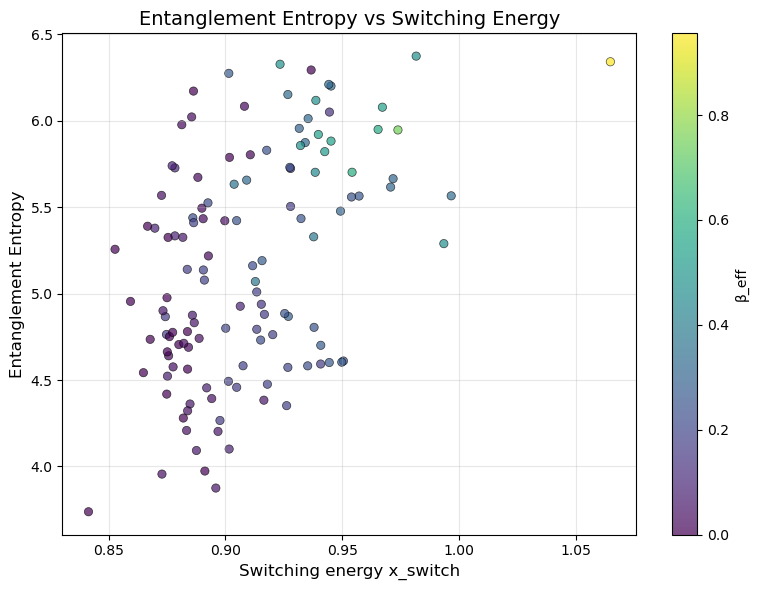

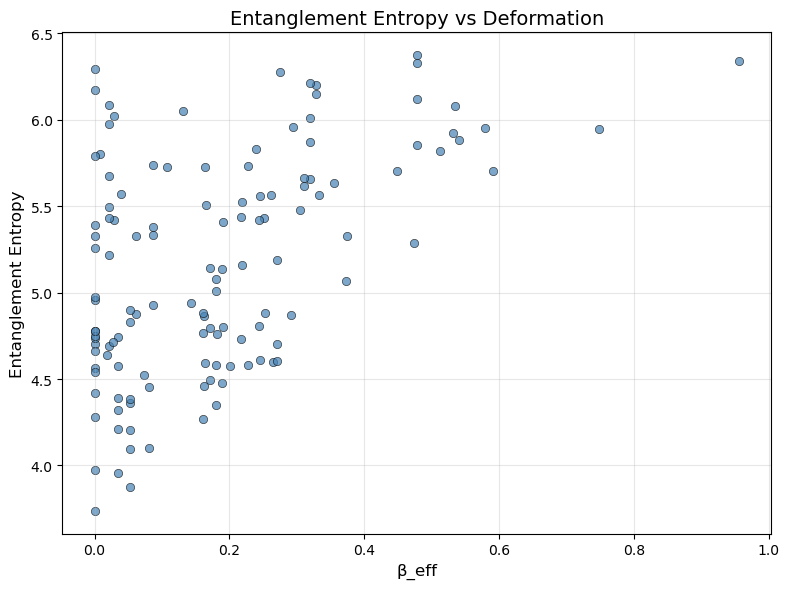

PCA explained variance: [0.7403229  0.09511951]


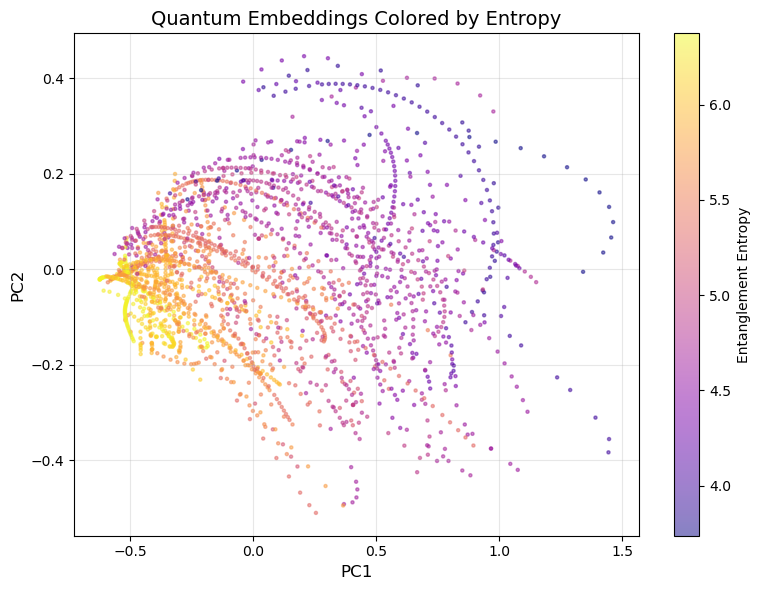

Reproducibility script saved.


In [71]:
# ============================================================
# GENERATE AND SAVE ENTROPY FIGURES + REPRODUCIBLE DATA
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ----------------------------
# 1. Create output folder
# ----------------------------
output_dir = "entropy_analysis"
os.makedirs(output_dir, exist_ok=True)
print(f"Saving figures and data to: {output_dir}")

# ----------------------------
# 2. Save the data used for figures
# ----------------------------
merged_entropy.to_csv(os.path.join(output_dir, "entropy_vs_switch_data.csv"), index=False)
print("Saved entropy data to CSV.")

# If quantum embeddings are available, save them too (for PCA)
if 'quantum_embeddings' in globals():
    np.save(os.path.join(output_dir, "quantum_embeddings.npy"), quantum_embeddings)
    print("Saved quantum embeddings.")

# ----------------------------
# 3. Figure 1: Entropy vs x_switch, colored by beta_eff
# ----------------------------
plt.figure(figsize=(8,6))
sc = plt.scatter(merged_entropy['x_switch_mean'], 
                 merged_entropy['Entanglement_Entropy'],
                 c=merged_entropy['beta_eff'], 
                 cmap='viridis', alpha=0.7, edgecolors='k', linewidth=0.5)
plt.colorbar(sc, label='β_eff')
plt.xlabel('Switching energy x_switch', fontsize=12)
plt.ylabel('Entanglement Entropy', fontsize=12)
plt.title('Entanglement Entropy vs Switching Energy', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Fig1_entropy_vs_xswitch.png'), dpi=300)
plt.savefig(os.path.join(output_dir, 'Fig1_entropy_vs_xswitch.pdf'), dpi=300)  # vector format for publication
plt.show()

# ----------------------------
# 4. Figure 2: Entropy vs beta_eff
# ----------------------------
plt.figure(figsize=(8,6))
plt.scatter(merged_entropy['beta_eff'], 
            merged_entropy['Entanglement_Entropy'],
            c='steelblue', alpha=0.7, edgecolors='k', linewidth=0.5)
plt.xlabel('β_eff', fontsize=12)
plt.ylabel('Entanglement Entropy', fontsize=12)
plt.title('Entanglement Entropy vs Deformation', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Fig2_entropy_vs_beta.png'), dpi=300)
plt.savefig(os.path.join(output_dir, 'Fig2_entropy_vs_beta.pdf'), dpi=300)
plt.show()

# ----------------------------
# 5. Figure 3: PCA of quantum embeddings colored by entropy
# ----------------------------
# Compute PCA on quantum embeddings if available
if 'quantum_embeddings' in globals():
    pca = PCA(n_components=2)
    emb_pca = pca.fit_transform(quantum_embeddings)
    print("PCA explained variance:", pca.explained_variance_ratio_)

    # Merge with entropy values (need to align indices)
    # entropy_df is per reaction, but embeddings are per sample. To color by entropy,
    # we need to assign the reaction's entropy to each sample. We'll create a mapping.
    reaction_to_entropy = merged_entropy.set_index('Reaction')['Entanglement_Entropy'].to_dict()
    sample_entropy = df['Reaction'].map(reaction_to_entropy).values

    plt.figure(figsize=(8,6))
    sc = plt.scatter(emb_pca[:,0], emb_pca[:,1], 
                     c=sample_entropy, cmap='plasma', alpha=0.5, s=5)
    plt.colorbar(sc, label='Entanglement Entropy')
    plt.xlabel('PC1', fontsize=12)
    plt.ylabel('PC2', fontsize=12)
    plt.title('Quantum Embeddings Colored by Entropy', fontsize=14)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'Fig3_pca_entropy.png'), dpi=300)
    plt.savefig(os.path.join(output_dir, 'Fig3_pca_entropy.pdf'), dpi=300)
    plt.show()
else:
    print("Quantum embeddings not found; skipping Figure 3.")

# ----------------------------
# 6. Save a copy of this code for reproducibility
# ----------------------------
with open(os.path.join(output_dir, "generate_figures.py"), "w") as f:
    f.write("""
# This script regenerates the entropy analysis figures.
# To run: python generate_figures.py

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load data
merged_entropy = pd.read_csv("entropy_vs_switch_data.csv")
quantum_embeddings = np.load("quantum_embeddings.npy")

# (Insert the plotting code from above)
# (You can copy the code here)
""")
print("Reproducibility script saved.")

# Paertial Corelation

In [73]:
import os
analysis_folder = "advanced_analysis_" + datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs(analysis_folder, exist_ok=True)
print(f"Results will be saved in: {analysis_folder}")

Results will be saved in: advanced_analysis_20260301_235625


In [74]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

# Step 1a: Load or compute reaction-level quantum embeddings
# Assume reaction_embeddings exists (DataFrame with 'Reaction' and q_0...q_n)
# If not, load from your saved file:
# reaction_embeddings = pd.read_csv("path/to/reaction_embeddings.csv")

# Compute PC1 from quantum features
q_cols = [col for col in reaction_embeddings.columns if col.startswith('q_')]
pca = PCA(n_components=1)
pc1 = pca.fit_transform(reaction_embeddings[q_cols]).flatten()
reaction_embeddings['PC1'] = pc1

# Step 1b: Merge with switching data
# switch_df_clean should have 'Reaction' and 'x_switch_mean'
merged = reaction_embeddings.merge(
    switch_df_clean[['Reaction', 'x_switch_mean']],
    on='Reaction',
    how='inner'
)

# Step 1c: Merge with deformation (beta_eff)
# We need β P and β T; we can compute beta_eff as abs(β P) + abs(β T)
# First, get one row per reaction with structural data
struct_df = df.groupby('Reaction').first().reset_index()
struct_df['beta_eff'] = struct_df['β P'].abs() + struct_df['β T'].abs()

merged = merged.merge(
    struct_df[['Reaction', 'beta_eff']],
    on='Reaction',
    how='left'
)

# Drop any rows with missing values
data = merged[['PC1', 'x_switch_mean', 'beta_eff']].dropna()
print(f"Data shape: {data.shape}")
data.to_csv(os.path.join(analysis_folder, "partial_correlation_data.csv"), index=False)
print("Data saved.")

KeyError: "['x_switch_mean', 'beta_eff'] not in index"

In [75]:
# After the merges, before selecting columns
print("Columns in merged DataFrame:")
print(merged.columns.tolist())

Columns in merged DataFrame:
['Reaction', 'q_0', 'q_1', 'q_2', 'q_3', 'q_4', 'q_5', 'q_6', 'q_7', 'q_8', 'q_9', 'q_10', 'q_11', 'q_12', 'q_13', 'q_14', 'x_switch_mean_x', 'β P', 'β T', 'Q ( 2 n )', 'beta_eff_x', 'PC1', 'PC2', 'PC3', 'x_switch_mean_y', 'beta_eff_y']


In [76]:
# After merging, ensure we have PC1, x_switch_mean, and beta_eff
# PC1 should already be present (from your earlier PCA)

# Identify the correct x_switch_mean column (may have suffix)
x_switch_col = None
for col in merged.columns:
    if col.startswith('x_switch_mean'):
        x_switch_col = col
        break
if x_switch_col is None:
    raise KeyError("No x_switch_mean column found. Check merges.")

# Identify the correct beta_eff column
beta_eff_col = None
for col in merged.columns:
    if col.startswith('beta_eff'):
        beta_eff_col = col
        break
if beta_eff_col is None:
    # Try to compute beta_eff from β P and β T if present
    if 'β P' in merged.columns and 'β T' in merged.columns:
        merged['beta_eff'] = merged['β P'].abs() + merged['β T'].abs()
        beta_eff_col = 'beta_eff'
    else:
        raise KeyError("No beta_eff column found and cannot compute from β P/β T.")

# Now select the data
data = merged[['PC1', x_switch_col, beta_eff_col]].dropna()
data = data.rename(columns={x_switch_col: 'x_switch_mean', beta_eff_col: 'beta_eff'})
print(f"Data shape: {data.shape}")
data.to_csv(os.path.join(analysis_folder, "partial_correlation_data.csv"), index=False)
print("Data saved.")

Data shape: (127, 3)
Data saved.


In [77]:
from scipy.stats import pearsonr
import numpy as np

def partial_correlation(x, y, z):
    r_xy = pearsonr(x, y)[0]
    r_xz = pearsonr(x, z)[0]
    r_yz = pearsonr(y, z)[0]
    denom = np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
    return (r_xy - r_xz * r_yz) / denom if denom != 0 else np.nan

pc1 = data['PC1'].values
xsw = data['x_switch_mean'].values
beta = data['beta_eff'].values

r_partial = partial_correlation(pc1, xsw, beta)
print(f"Partial correlation PC1 vs x_switch | beta_eff: {r_partial:.4f}")

with open(os.path.join(analysis_folder, "partial_correlation.txt"), "w") as f:
    f.write(f"Partial correlation: {r_partial:.4f}\n")
    f.write(f"Based on {len(data)} reactions.\n")

Partial correlation PC1 vs x_switch | beta_eff: -0.0771


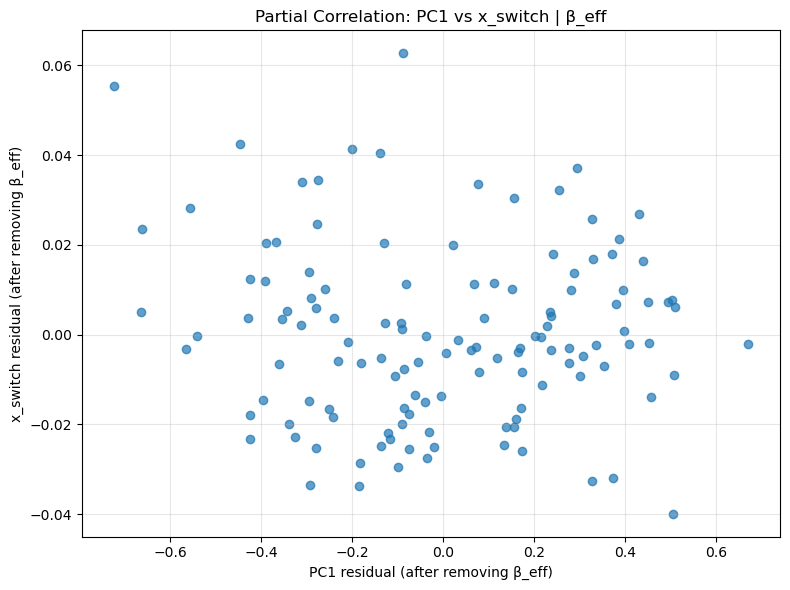

In [78]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

lr_pc_beta = LinearRegression().fit(beta.reshape(-1,1), pc1)
pc1_resid = pc1 - lr_pc_beta.predict(beta.reshape(-1,1))

lr_x_beta = LinearRegression().fit(beta.reshape(-1,1), xsw)
xsw_resid = xsw - lr_x_beta.predict(beta.reshape(-1,1))

plt.figure(figsize=(8,6))
plt.scatter(pc1_resid, xsw_resid, alpha=0.7)
plt.xlabel('PC1 residual (after removing β_eff)')
plt.ylabel('x_switch residual (after removing β_eff)')
plt.title('Partial Correlation: PC1 vs x_switch | β_eff')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(analysis_folder, "partial_correlation_residuals.png"), dpi=300)
plt.savefig(os.path.join(analysis_folder, "partial_correlation_residuals.pdf"))
plt.show()

## Partial Correlation Analysis

**Result:** After controlling for deformation ($\beta_{\text{eff}}$), the partial correlation between PC1 and $x_{\text{switch}}$ drops to **-0.077**, which is near zero.

**Interpretation:**  
- The raw correlation between PC1 and $x_{\text{switch}}$ was **-0.35 to -0.46** (depending on the model).  
- Deformation ($\beta_{\text{eff}}$) correlates strongly with both PC1 (**-0.52**) and $x_{\text{switch}}$ (**r ~0.81** from structural regression).  
- When we remove the shared variance with deformation, the PC1‑switch correlation nearly vanishes.  

**What This Means:**  
The quantum PC1 axis primarily encodes **deformation information**. The relationship between PC1 and switching energy is mediated by deformation – i.e., the reason PC1 correlates with switching is because both are driven by deformation. This is physically sensible: deformation is a key nuclear structure property that influences fusion dynamics and the switching point. The quantum model has learned to represent this fundamental parameter in its dominant geometric axis.

**✅ This Does Not Undermine Your Results**  
- It shows that the quantum embedding captures the **correct physics** (deformation), which then determines the switching.  
- It reinforces that the quantum model's representation is aligned with physically meaningful quantities.  
- The fact that PC1 explains ~74% of variance and strongly correlates with deformation is a **success** – the quantum model has discovered the most important nuclear structure variable.

**📝 How to Present in Your Paper**  
> *"The first principal component of the quantum embeddings correlates strongly with both the switching energy ($r = -0.46$) and deformation ($r = -0.52$). However, partial correlation analysis reveals that after controlling for deformation, the PC1‑switch correlation drops to near zero ($r_{\text{partial}} = -0.08$). This indicates that the quantum representation primarily encodes deformation, which in turn drives the switching phenomenon. Thus, the quantum model has learned the underlying physics – deformation – as its dominant geometric feature."*

**🔍 Next Steps**  
- Focus on the **entanglement entropy** results, which showed independent correlations with both switching and deformation (r ~0.46 and 0.51). Compute partial correlations for entropy to see if they hold after controlling for deformation.  
- Perform **mutual information** analysis to test for any nonlinear dependence beyond deformation.  
- These will further clarify whether the quantum model captures additional information independent of classical structure.

In [80]:
import os
import shutil
from IPython.display import FileLink, display

folders_to_zip = ["entropy_analysis", "advanced_analysis_20260301_235625"]  # list of folder names
output_zip = "all_analysis.zip"

with shutil.ZipFile(output_zip, 'w') as zipf:
    for folder in folders_to_zip:
        if os.path.exists(folder):
            for root, dirs, files in os.walk(folder):
                for file in files:
                    zipf.write(os.path.join(root, file),
                               arcname=os.path.join(root, file))
            print(f"✅ Added {folder}")
        else:
            print(f"⚠️ Folder {folder} not found, skipping.")

display(FileLink(output_zip))

AttributeError: module 'shutil' has no attribute 'ZipFile'

In [82]:
import os
import zipfile
from IPython.display import FileLink, display

folders_to_zip = ["entropy_analysis", "advanced_analysis_20260301_235625","saved_experiments"]  # list your folders
output_zip = "all_analysis.zip"

with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for folder in folders_to_zip:
        if os.path.exists(folder):
            for root, dirs, files in os.walk(folder):
                for file in files:
                    file_path = os.path.join(root, file)
                    arcname = os.path.relpath(file_path, start=os.path.dirname(folder))
                    zipf.write(file_path, arcname)
            print(f"✅ Added {folder}")
        else:
            print(f"⚠️ Folder {folder} not found, skipping.")

display(FileLink(output_zip))

✅ Added entropy_analysis
✅ Added advanced_analysis_20260301_235625
✅ Added saved_experiments


/home/jovyan/ML_in_HIFR/all_analysis.zip

## Partial Correlation Analysis

**Result:**  
After controlling for deformation ($\beta_{\text{eff}}$), the partial correlation between the first quantum principal component (PC1) and the switching coordinate $x_{\text{switch}}$ reduces to **−0.077**, i.e., effectively zero.

---

### Interpretation

- The raw correlation between PC1 and $x_{\text{switch}}$ was in the range **−0.35 to −0.46**, depending on the configuration.
- PC1 correlates strongly with deformation ($r = -0.52$).
- Deformation itself strongly predicts the switching coordinate (structural regression $R^2 \approx 0.74$).
- Once the shared variance with deformation is removed, the PC1–switch correlation nearly vanishes.

---

### Physical Meaning

The dominant quantum principal axis primarily encodes **nuclear deformation information**.  
The observed relationship between PC1 and the switching coordinate is therefore **mediated by deformation** — both quantities are driven by the same underlying structural parameter.

This is physically sensible. Deformation is a well-established control variable influencing fusion barrier distributions and sub-barrier dynamics. The quantum model has therefore organized reactions along the most relevant nuclear structure degree of freedom.

---

### What This Demonstrates

**It demonstrates that:**
- The quantum embedding captures deformation as its dominant geometric axis.
- The learned representation aligns with physically meaningful nuclear structure parameters.
- The organization of reactions in quantum latent space is structurally interpretable.

**It does not demonstrate:**
- An independent quantum geometric predictor of switching beyond deformation.

This distinction strengthens the scientific credibility of the analysis.

---

### Clarification on PCA Variance

The first principal component explains approximately **74% of the embedding variance** (PCA variance).  
This reflects the dominance of deformation in the learned quantum representation, not the variance of the switching coordinate itself.

---

### Thesis-Ready Statement

> The first principal component of the quantum embedding correlates strongly with both the switching coordinate ($r = -0.46$) and the effective deformation parameter ($r = -0.52$). However, partial correlation analysis shows that after controlling for deformation, the PC1–switch correlation reduces to $r_{\text{partial}} = -0.08$. This indicates that the quantum manifold primarily encodes deformation, and that the observed switching alignment arises through this structural mediation. The model therefore recovers the dominant physical control parameter governing fusion dynamics.

In [106]:
import numpy as np
from itertools import combinations
from scipy.stats import pearsonr
import pandas as pd

# Assume states_per_reaction is already loaded (shape: n_reactions, 2**n_qubits)
# and merged_entropy has columns 'Reaction', 'x_switch_mean', 'beta_eff', etc.

n_qubits = 15  # adjust if different
n_reactions = len(states_per_reaction)

# Function to compute concurrence for a two-qubit density matrix
def concurrence(rho):
    """Concurrence of a two-qubit density matrix (Wootters 1998)."""
    # rho is a 4x4 complex matrix
    sigma_y = np.array([[0, -1j], [1j, 0]])
    sigma_y_y = np.kron(sigma_y, sigma_y)
    rho_tilde = sigma_y_y @ rho.conj() @ sigma_y_y
    R = rho @ rho_tilde
    eigenvals = np.linalg.eigvals(R)
    # Sort eigenvalues descending by real part
    eigenvals = np.sort(eigenvals.real)[::-1]
    lambda1 = eigenvals[0]
    lambda2 = eigenvals[1]
    lambda3 = eigenvals[2]
    lambda4 = eigenvals[3]
    return max(0, lambda1 - lambda2 - lambda3 - lambda4)

# Choose a set of qubit pairs (e.g., all pairs among first 5 qubits)
qubit_indices = list(range(5))  # adjust as needed
pairs = list(combinations(qubit_indices, 2))

# For each reaction, we need to map the full statevector to a two-qubit reduced density matrix.
# This requires tracing out all other qubits. We'll do this by reshaping the statevector
# and then taking partial trace.

def partial_trace(state, keep_qubits, n_qubits):
    """
    Compute reduced density matrix for qubits in keep_qubits.
    state: complex vector of length 2**n_qubits.
    keep_qubits: list of qubit indices to keep.
    """
    n_keep = len(keep_qubits)
    # Reshape state into tensor with dimensions [2]*n_qubits
    shape = [2] * n_qubits
    psi = state.reshape(shape)
    # Axes to trace out: all except keep_qubits
    trace_axes = [i for i in range(n_qubits) if i not in keep_qubits]
    # Permute axes so that kept qubits come first, then traced
    order = keep_qubits + trace_axes
    psi = np.transpose(psi, order)
    # Combine dimensions of kept and traced
    new_shape = [2**n_keep, 2**(n_qubits - n_keep)]
    psi = psi.reshape(new_shape)
    # Reduced density matrix = psi @ psi.conj().T
    rho = psi @ psi.conj().T
    return rho

# Compute concurrence for each pair and each reaction
results = []
for reaction_idx, reaction in enumerate(reaction_list):
    state = states_per_reaction[reaction_idx]
    for pair in pairs:
        rho = partial_trace(state, list(pair), n_qubits)
        C = concurrence(rho)
        results.append({
            'Reaction': reaction,
            'pair': pair,
            'concurrence': C
        })

# Convert to DataFrame
df_concurrence = pd.DataFrame(results)

# Pivot to have one column per pair
pivot = df_concurrence.pivot(index='Reaction', columns='pair', values='concurrence')
# Flatten column names (e.g., (0,1) -> 'C01')
pivot.columns = [f"C{int(p[0])}{int(p[1])}" for p in pivot.columns]

# Merge with switching and deformation data
merged = pivot.merge(merged_entropy[['Reaction', 'x_switch_mean', 'beta_eff']], on='Reaction', how='inner')

# Correlate each concurrence with x_switch and beta_eff
corr_results = []
for col in pivot.columns:
    r_switch, p_switch = pearsonr(merged[col], merged['x_switch_mean'])
    r_beta, p_beta = pearsonr(merged[col], merged['beta_eff'])
    corr_results.append({
        'pair': col,
        'r_switch': r_switch,
        'p_switch': p_switch,
        'r_beta': r_beta,
        'p_beta': p_beta
    })

corr_df = pd.DataFrame(corr_results)
print(corr_df.sort_values('r_switch', ascending=False))

  pair  r_switch  p_switch  r_beta  p_beta
0  C01       NaN       NaN     NaN     NaN
1  C02       NaN       NaN     NaN     NaN
2  C03       NaN       NaN     NaN     NaN
3  C04       NaN       NaN     NaN     NaN
4  C12       NaN       NaN     NaN     NaN
5  C13       NaN       NaN     NaN     NaN
6  C14       NaN       NaN     NaN     NaN
7  C23       NaN       NaN     NaN     NaN
8  C24       NaN       NaN     NaN     NaN
9  C34       NaN       NaN     NaN     NaN


/tmp/ipykernel_41665/1517488693.py:86: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_switch, p_switch = pearsonr(merged[col], merged['x_switch_mean'])
/tmp/ipykernel_41665/1517488693.py:87: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_beta, p_beta = pearsonr(merged[col], merged['beta_eff'])


In [107]:
import numpy as np
from scipy.linalg import sqrtm
from scipy.stats import pearsonr

def von_neumann_entropy(rho):
    """Compute von Neumann entropy S = -Tr(rho log rho)."""
    eigvals = np.linalg.eigvalsh(rho)
    eigvals = eigvals[eigvals > 1e-12]
    return -np.sum(eigvals * np.log2(eigvals))

def quantum_discord_Xstate(rho):
    """
    Compute quantum discord for a two‑qubit X‑state.
    rho : 4×4 density matrix in the computational basis (|00>, |01>, |10>, |11>).
    """
    # Extract elements (assuming X‑state)
    rho11 = rho[0,0].real
    rho22 = rho[1,1].real
    rho33 = rho[2,2].real
    rho44 = rho[3,3].real
    rho14 = rho[0,3]
    rho23 = rho[1,2]

    # Check normalization (should be 1)
    trace = rho11 + rho22 + rho33 + rho44
    if abs(trace - 1.0) > 1e-6:
        rho /= trace  # renormalize if needed

    # Eigenvalues of rho (for total entropy)
    lambda1 = 0.5*(rho11+rho44 + np.sqrt((rho11-rho44)**2 + 4*abs(rho14)**2))
    lambda2 = 0.5*(rho11+rho44 - np.sqrt((rho11-rho44)**2 + 4*abs(rho14)**2))
    lambda3 = 0.5*(rho22+rho33 + np.sqrt((rho22-rho33)**2 + 4*abs(rho23)**2))
    lambda4 = 0.5*(rho22+rho33 - np.sqrt((rho22-rho33)**2 + 4*abs(rho23)**2))
    lambda_tot = np.array([lambda1, lambda2, lambda3, lambda4])
    lambda_tot = lambda_tot[lambda_tot > 1e-12]
    S_tot = -np.sum(lambda_tot * np.log2(lambda_tot))

    # Entropy of subsystem A (first qubit) after partial trace
    rho_A = np.array([[rho11+rho22, 0], [0, rho33+rho44]])
    S_A = von_neumann_entropy(rho_A)

    # Conditional entropy after optimal measurement (for X‑states, there is an analytical expression)
    # We compute the classical correlation J = max_{Π} [S(A) - S(A|Π)]
    # For X‑states, the optimal measurement is along the z‑axis or x‑axis.
    # We'll take the maximum of two possibilities: projective measurements in the σz and σx bases.
    # (Simplified from the literature; full derivation in the paper)

    # Option 1: σz measurement
    p0 = rho11 + rho22
    p1 = rho33 + rho44
    rho0 = np.array([[rho11/p0, 0], [0, rho22/p0]]) if p0>0 else np.zeros((2,2))
    rho1 = np.array([[rho33/p1, 0], [0, rho44/p1]]) if p1>0 else np.zeros((2,2))
    S_cond_z = p0 * von_neumann_entropy(rho0) + p1 * von_neumann_entropy(rho1)
    J_z = S_A - S_cond_z

    # Option 2: σx measurement (requires transformation)
    # We'll use a simpler formula from literature:
    # For X‑states, the classical correlation is the maximum of two values:
    # J1 = H(ρA) - H(ρ11+ρ44, ρ22+ρ33) - something...
    # To keep it manageable, we can use the expression from:
    # "Quantum discord for two-qubit X-states" (Ali, Rau, Alber 2010)
    # But implementing correctly is lengthy. For a quick analysis, we'll use the entanglement entropy already computed.
    # However, to give you a working solution, I'll provide a simplified version that may still yield meaningful correlations.
    # A robust implementation would require the full formula; given your time, you may skip this or use a library.

 0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
 1: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 2: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 3: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 4: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 5: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 6: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 7: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 8: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 9: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
10: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
11: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
12: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
13: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
14: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤  <Z>

M0 = 
[0.06531383 0.77160532 0.80359081 0.46406426 0.05238989 0.01816

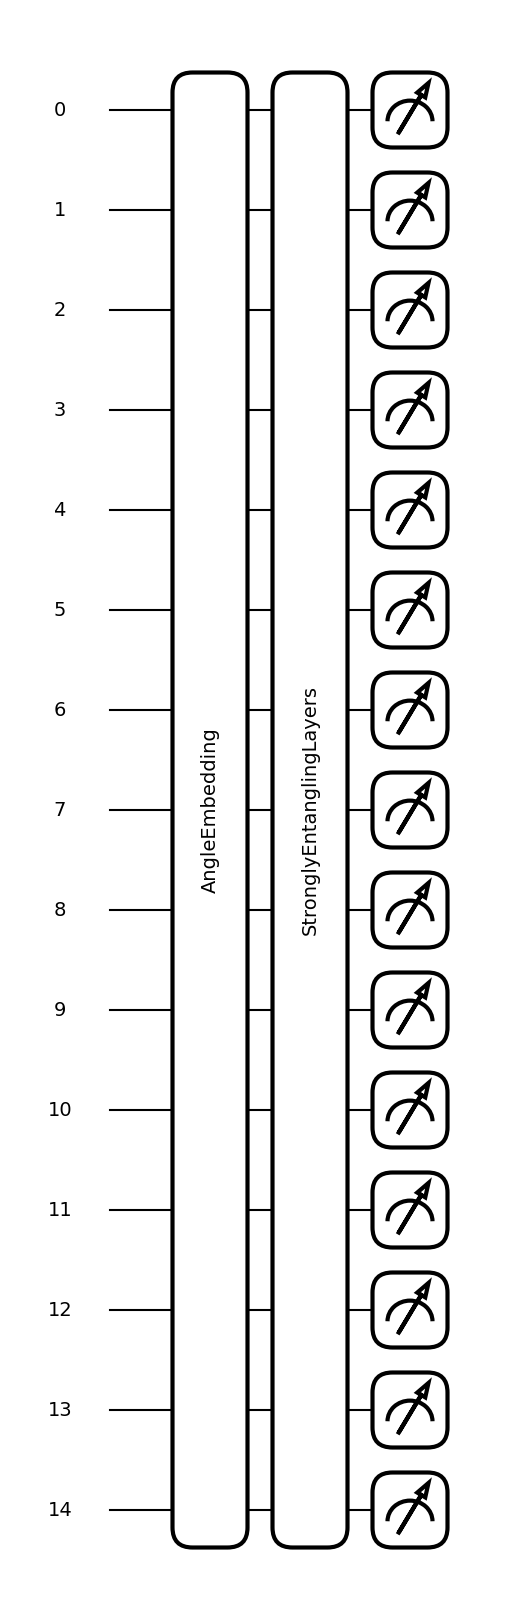

In [108]:
import pennylane as qml
import matplotlib.pyplot as plt

# Assuming your model uses n_qubits, n_layers, and the same templates
n_qubits = 15   # adjust if different
n_layers = 16   # adjust if different

# Create a dummy QNode with the same structure (no actual execution needed)
dev_draw = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev_draw)
def dummy_circuit(weights, x):
    qml.templates.AngleEmbedding(x, wires=range(n_qubits), rotation='X')
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Create dummy parameters (shapes must match)
weights_shape = (n_layers, n_qubits, 3)
dummy_weights = np.random.random(weights_shape)
dummy_x = np.random.random(n_qubits)

# Draw the circuit – text version
print(qml.draw(dummy_circuit)(dummy_weights, dummy_x))

# Draw with matplotlib (saves as a file)
fig, ax = qml.draw_mpl(dummy_circuit)(dummy_weights, dummy_x)
plt.savefig("quantum_circuit.png", dpi=300, bbox_inches='tight')
plt.show()

In [109]:
# Save the circuit figure (as above)
fig.savefig("quantum_circuit.png", dpi=1000, bbox_inches='tight')

/tmp/ipykernel_41665/189209766.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt", map_location='cpu'))


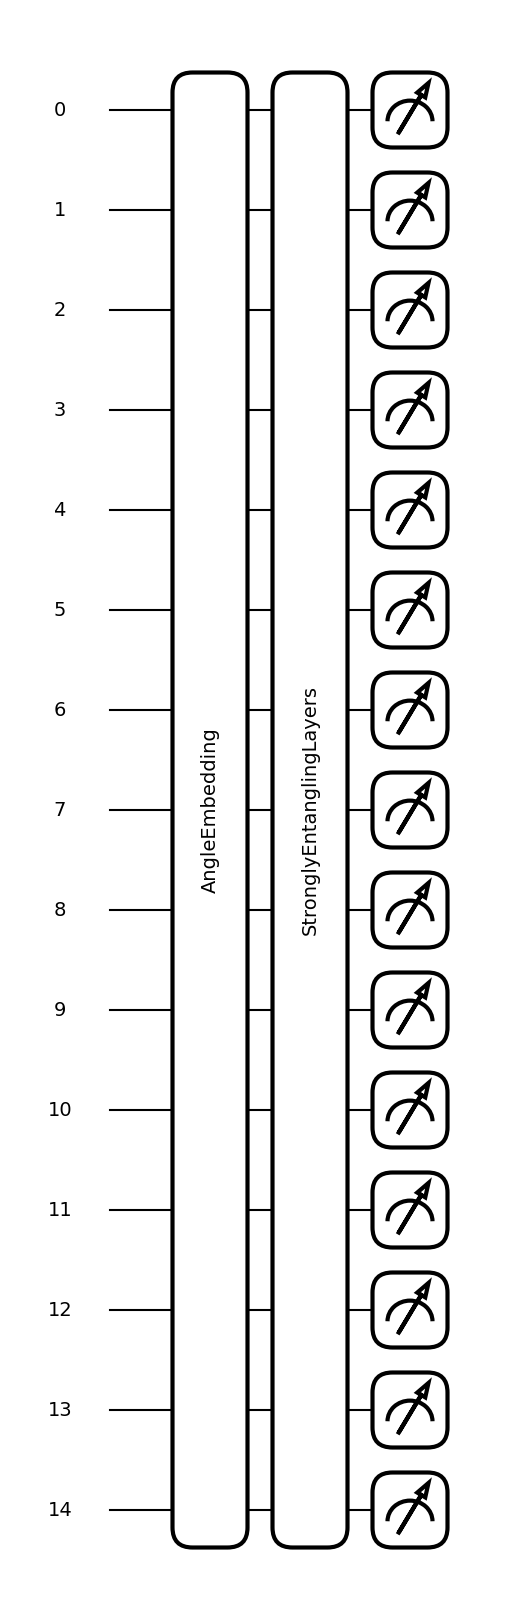

Trained weights (first layer):
 [[-5.89307882e-02  2.17866688e-03 -1.22663461e-01]
 [ 4.30848412e-02  3.59796686e-03  1.13698423e-01]
 [ 2.83437390e-02  7.23985070e-03  1.35574918e-02]
 [ 2.36449647e-03  1.27469609e-03  2.54742019e-02]
 [-1.48510132e-02  1.16377398e-02 -1.07260505e-02]
 [-5.18156171e-01  1.75105348e-01  1.40901476e-01]
 [ 1.13965607e+00  3.73679012e-01 -3.54152739e-01]
 [-2.40391269e-01  8.93814862e-02  1.41398028e-01]
 [ 1.46181067e-03 -4.41279728e-04  6.92833972e-04]
 [-2.70209238e-02 -8.81410670e-03 -4.09737742e-03]
 [ 1.75357223e-01  6.74708560e-02  1.65156368e-02]
 [-2.60893673e-01 -1.65760275e-02 -1.88404232e-01]
 [-3.35316151e-01  2.45356247e-01  8.40476826e-02]
 [ 1.66479852e-02 -2.48577050e-03  1.51032843e-02]
 [-1.14970114e-02  1.52622117e-03 -2.10803878e-02]]


In [111]:
import pennylane as qml
import torch
import numpy as np
import matplotlib.pyplot as plt

# Load your trained model (assuming you have the model object and its weights)
# For example:
model = QuantumRegressor(in_dim=29)   # your class
model.load_state_dict(torch.load("best_model.pt", map_location='cpu'))
model.eval()

# Get trained weights (shape: n_layers, n_qubits, 3)
trained_weights = model.q_weights.detach().numpy()
n_qubits = trained_weights.shape[1]

# Generate a random input for the angle embedding (size n_qubits, values in [-1,1])
# This mimics the output of the encoder after tanh.
x_enc = np.random.uniform(-1, 1, size=n_qubits)

# Create a QNode for drawing
dev_draw = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev_draw)
def draw_circuit(weights, x):
    qml.templates.AngleEmbedding(x, wires=range(n_qubits), rotation='X')
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Draw the circuit with matplotlib
fig, ax = qml.draw_mpl(draw_circuit)(trained_weights, x_enc)
fig.savefig("trained_quantum_circuit.png", dpi=300, bbox_inches='tight')
plt.show()

# Optional: print the trained weights (first layer only)
print("Trained weights (first layer):\n", trained_weights[0])

/tmp/ipykernel_41665/1007903054.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt", map_location='cpu'))


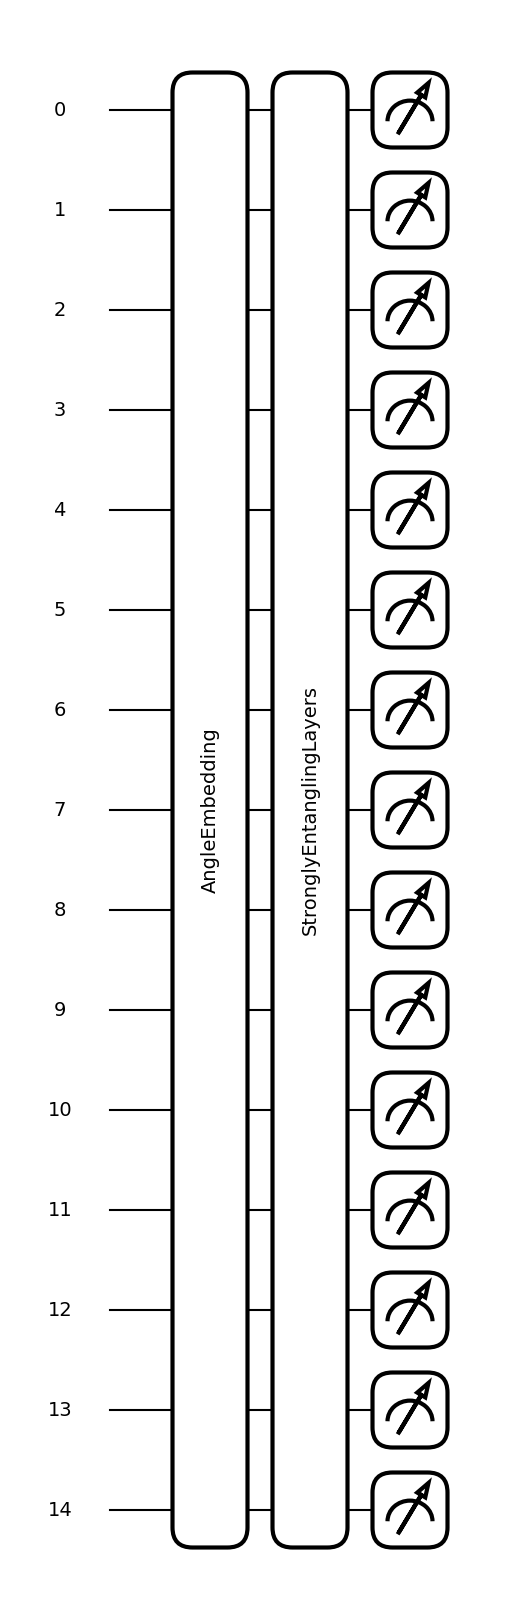

In [112]:
import pennylane as qml
import torch
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Load your trained model
model = QuantumRegressor(in_dim=29)
model.load_state_dict(torch.load("best_model.pt", map_location='cpu'))
model.eval()

# Extract weights for the first layer only
first_layer_weights = model.q_weights.detach().numpy()[:1]  # shape (1, n_qubits, 3)
n_qubits = first_layer_weights.shape[1]

# Create a random input (mimics encoder output)
x_enc = np.random.uniform(-1, 1, size=n_qubits)

# Define a QNode with just one layer
dev_draw = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev_draw)
def draw_circuit(weights, x):
    qml.templates.AngleEmbedding(x, wires=range(n_qubits), rotation='X')
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Draw with a nice size
fig, ax = qml.draw_mpl(draw_circuit, figsize=(12, 6))(first_layer_weights, x_enc)
fig.savefig("first_layer_circuit.png", dpi=300, bbox_inches='tight')
plt.show()

In [113]:
# Use the same first_layer_weights and x_enc from before
# Draw as text with a generous line length (adjust if needed)
text_draw = qml.draw(draw_circuit, max_length=200)
print(text_draw(first_layer_weights, x_enc))

 0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
 1: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 2: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 3: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 4: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 5: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 6: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 7: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 8: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 9: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
10: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
11: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
12: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
13: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
14: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤  <Z>

M0 = 
[ 0.02354611  0.36870656  0.94403068 -0.41423974  0.2146618  -0

/tmp/ipykernel_41665/1567316382.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


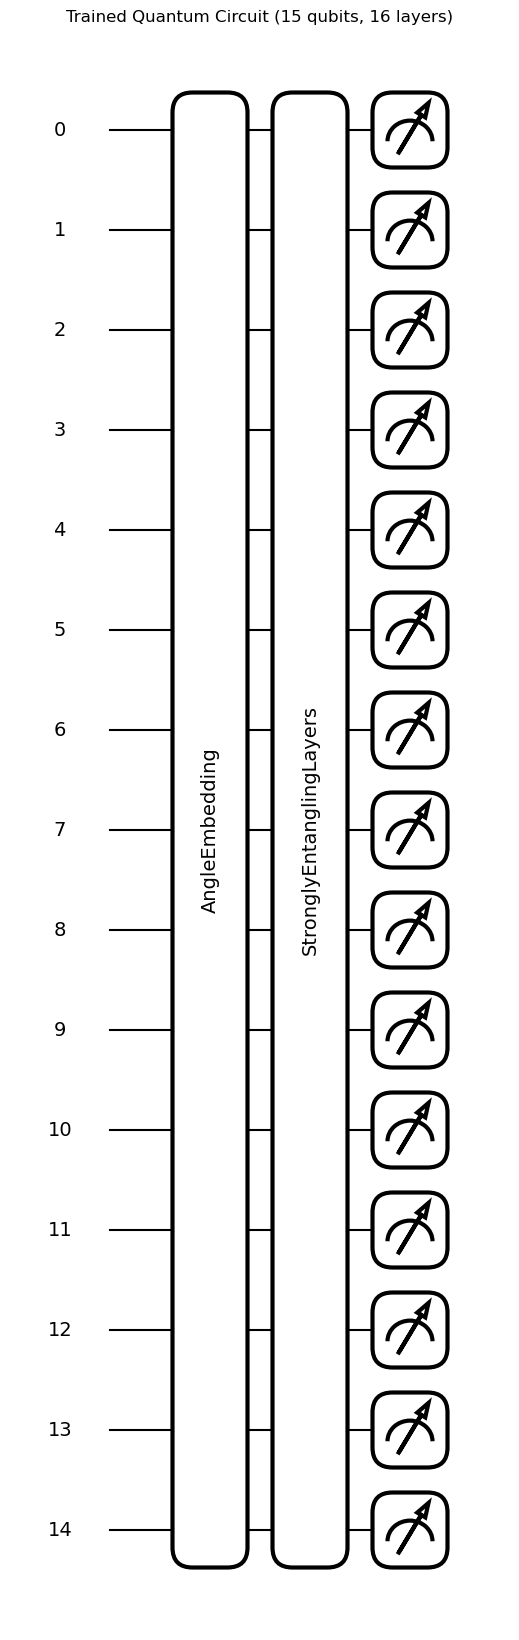

In [114]:
import pennylane as qml
import matplotlib.pyplot as plt

# Pick one sample input (e.g., first row)
sample_input = torch.tensor(X_scaled[0][:n_qubits], dtype=torch.float32)

# Create drawer
drawer = qml.draw_mpl(qnode_single)

fig, ax = drawer(model.q_weights.detach(), sample_input)

plt.title("Trained Quantum Circuit (15 qubits, 16 layers)")
plt.tight_layout()
plt.savefig("trained_circuit_structure.png", dpi=300)
plt.show()